# 🚀 完整DMPC框架: Flow Matching + CBF +MLP intercation





# 🔧 修正版 DMPC + Flow Matching 框架

---

## 📋 主要修改

本notebook是修正版,解决了原版本中的关键问题:

### ❌ 原版本问题
1. **Flow Matching预测了50步,但只使用了第2个点** - 浪费了预测信息
2. **缺少reward函数和value function** - 无法评估轨迹质量
3. **单步优化而非MPC** - 实际上是贪心算法

### ✅ 修正版改进
1. **完整利用Flow Matching预测** - 评估整条未来轨迹(50步)
2. **添加reward和value function** - 正确评估轨迹代价
3. **真正的MPC优化** - 基于未来N步做当前决策

---

## 🎯 核心架构

每一步DMPC循环:

```
1. 预测: Flow Matching预测未来50步 → [x₀, x₁, ..., x₄₉]
2. 评估: 计算总代价 J = Σ(reward₀→₄₈) + V(x₄₉)
3. 选择: 提取最优轨迹的第一步控制 u₀
4. 执行: 应用CBF确保安全,更新状态
5. 循环: 用新状态重新预测(滚动优化)
```

---

## 📝 新增函数

- `compute_stage_reward(x, u, goal, obstacles)` - 计算单步奖励
- `compute_terminal_value(x_terminal, goal, obstacles)` - 计算终端价值
- `evaluate_trajectory_cost(trajectory, ...)` - 评估整条轨迹
- `dmpc_step_corrected(...)` - 修正的DMPC单步优化
- `dmpc_rollout_corrected(...)` - 修正的完整滚动循环

---

## ⚙️ 关键参数

调用`dmpc_rollout_corrected`时的重要参数:

- `horizon=50` - 预测视野(每次预测多少步)
- `n_samples=3` - 采样数量(每次尝试几条候选轨迹)
- `dt=0.02` - 时间步长

---

## 🚀 运行说明

1. 按顺序运行所有cell
2. 观察输出中的`MPC_cost`值 - 这表示轨迹的总代价
3. `MPC_cost`应该随着接近目标而增加(变得不那么负)

---

**修正时间**: 2024-11-16  
**修正要点**: Flow Matching作为动态模型 + MPC优化框架 + CBF安全保证


In [2]:
# ===============================================================
# 导入库和环境设置
# ===============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cvxpy as cp
import os

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  使用设备: {device}")
print(f"📦 PyTorch版本: {torch.__version__}")
print(f"📦 CVXPY版本: {cp.__version__}")
print()

# 设置matplotlib
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 10

print("✅ 环境设置完成")

🖥️  使用设备: cuda
📦 PyTorch版本: 2.8.0+cu129
📦 CVXPY版本: 1.7.3

✅ 环境设置完成


In [3]:
# ===============================================================
# Flow Matching 基础组件（简化版：FM + ODE + CBF）
# ===============================================================

import torch
import torch.nn as nn

# ---------- 1. 如果没有 fmtorch，就用简化的 CondOTScheduler / AffinePath / ModelWrapper ----------
try:
    from fmtorch.scheduler import CondOTScheduler
    from fmtorch.path import AffinePath
    from fmtorch.utils import ModelWrapper
    FMTORCH_AVAILABLE = True
    print("✅ fmtorch 可用，训练会用到 CondOTScheduler / AffinePath")
except ImportError:
    FMTORCH_AVAILABLE = False
    print("⚠️ fmtorch 未安装，将使用简化版 CondOTScheduler / AffinePath / ModelWrapper（只用于训练）")
    
    class CondOTScheduler:
        def sigma_t(self, t):
            # 这里只是占位实现，保证训练代码能跑
            return 1e-5 * torch.ones_like(t)

    class AffinePath:
        def __init__(self, scheduler):
            self.scheduler = scheduler
        
        def sample(self, x_0, x_1, t):
            """
            简单线性插值路径:
                x_t = (1 - t) * x_0 + t * x_1
                dx_t = x_1 - x_0
            """
            if t.dim() == 1:
                t = t.view(-1, 1, 1)  # (B,1,1)
            x_t = (1 - t) * x_0 + t * x_1
            dx_t = x_1 - x_0

            class PathSample:
                pass
            sample = PathSample()
            sample.x_t = x_t
            sample.dx_t = dx_t
            sample.t = t
            return sample

    class ModelWrapper(nn.Module):
        """
        简单包装一下模型，统一接口：
            wrapped_model(x, t) -> model(x, t)
        """
        def __init__(self, model):
            super().__init__()
            self.model = model
        
        def forward(self, x, t, **kwargs):
            if t.dim() == 2:
                t = t.squeeze(-1)
            return self.model(x, t)

# ---------- 2. 椭圆障碍物的 h(x) 和 ∇h(x)（世界坐标下） ----------
def ellipse_h_grad_batch(x_world_2N: torch.Tensor, ellipse: dict):
    """
    x_world_2N: (2, N)
    ellipse: {"center": np.array([cx,cy]), "radius": r}

    返回:
        h_e:    (N,)   h(x) = ||x-c||^2 - r^2
        grad_w: (N,2) ∇h(x) = 2(x-c)
    """
    if not torch.is_tensor(x_world_2N):
        x_world_2N = torch.as_tensor(x_world_2N, dtype=torch.float32)

    center = ellipse["center"]
    radius = ellipse["radius"]

    if not torch.is_tensor(center):
        center = torch.as_tensor(center, dtype=x_world_2N.dtype, device=x_world_2N.device)

    x_N2 = x_world_2N.transpose(0, 1)   # (N,2)
    delta = x_N2 - center.view(1, 2)    # (N,2)

    dist_sq = (delta ** 2).sum(dim=1)   # (N,)
    h_e = dist_sq - float(radius) ** 2  # (N,)

    grad_w = 2.0 * delta                # (N,2)
    return h_e, grad_w


# ---------- 3. CBF 速度投影：直接在世界坐标里修 v ----------
@torch.no_grad()

def cbf_project_velocity_world(
    x_1x2N: torch.Tensor,
    v_nom_1x2N: torch.Tensor,
    ellipses,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 5,
    # ★ 新增：两车互相避障相关
    other_agent_traj: torch.Tensor = None,   # (1,2,N) or None
    agent_safe_radius: float = 0.5,
    # ★ 新增：压强 + α(h) 参数
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    CBF 投影（世界坐标）：
      - 对静态椭圆障碍 + 另一辆车，都加 CBF 约束
      - α(h) = γ(x) * h，其中 γ(x) = γ_min + w_p * P(x)，压强 P(x)=k/d^n

    输入:
      - x_1x2N:      (1,2,N) 当前整条轨迹
      - v_nom_1x2N:  (1,2,N) 名义速度场（FM 输出）
      - ellipses:    障碍物 [{"center": np.array, "radius": r}, ...] 或 []
      - other_agent_traj: (1,2,N)，另一辆车的整条轨迹（两车对开场景）
    """
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)
    has_other = other_agent_traj is not None

    # 如果既没有障碍又没有对车，那就不用 CBF
    if (not has_ellipses) and (not has_other):
        return v_nom_1x2N

    B, D, N = x_1x2N.shape  # (1,2,N)
    assert B == 1 and D == 2

    x_world_2N = x_1x2N.squeeze(0)  # (2,N)
    v_now = v_nom_1x2N.squeeze(0)   # (2,N)

    # ============================================================
    # 1) 计算两车之间的压强 P(x)
    # ============================================================
    if has_other:
        x_other_2N = other_agent_traj.squeeze(0)  # (2,N)
        delta_agent = x_world_2N.transpose(0, 1) - x_other_2N.transpose(0, 1)  # (N,2)
        dist = torch.norm(delta_agent, dim=1).clamp_min(1e-3)  # (N,)
        P = press_k / dist.pow(press_n)                        # (N,)
    else:
        P = torch.zeros(N, device=x_world_2N.device)

    # γ(x) = γ_min + w_p * P
    gamma_x = gamma_min + w_p * P  # (N,)

    # ============================================================
    # 2) CBF 投影主循环
    # ============================================================
    for _ in range(max(1, passes)):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (N,2)

        # ---------- (a) 静态椭圆障碍 CBF ----------
        if has_ellipses:
            for e in ellipses:
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)  # h: (N,), grad: (N,2)
                h_eff = h_e - float(extra_margin)                  # 安全 margin

                # α(h) = γ(x) * h
                alpha_h = gamma_x * h_eff                          # (N,)

                # CBF: ∇h·v + α(h) ≥ 0
                s_e = (grad_w * v_T).sum(dim=1) + alpha_h          # (N,)

                all_s.append(s_e)
                all_a.append(grad_w)

        # ---------- (b) 两车之间的 CBF ----------
        if has_other:
            # h_agent(x) = ||x - x_other||^2 - R_safe^2
            h_agent = dist**2 - agent_safe_radius**2              # (N,)
            grad_agent = 2.0 * delta_agent                        # (N,2)

            alpha_h_agent = gamma_x * h_agent                     # (N,)
            s_agent = (grad_agent * v_T).sum(dim=1) + alpha_h_agent

            all_s.append(s_agent)
            all_a.append(grad_agent)

        if len(all_s) == 0:
            # 没有任何约束
            break

        S_cat = torch.stack(all_s, dim=0)          # (E,N)
        s_min, idx_min = torch.min(S_cat, dim=0)   # (N,)

        A_cat = torch.stack(all_a, dim=0)          # (E,N,2)
        a_pick = A_cat.gather(
            0,
            idx_min.view(1, -1, 1).expand(1, S_cat.size(1), 2)
        ).squeeze(0)  # (N,2)

        # ---------- 只修正违反约束的点 ----------
        mask = (s_min < 0.0)
        if mask.any():
            a_sq = (a_pick ** 2).sum(dim=1).clamp_min(1e-12)
            coef = torch.zeros_like(s_min)
            coef[mask] = -s_min[mask] / a_sq[mask]     # λ = -s / ||a||^2

            delta = (coef.view(1, -1) * a_pick.transpose(0, 1))  # (2,N)

            if max_corr_norm > 0:
                dnorm = delta.norm(dim=0).clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale

            v_now = v_now + delta

    return v_now.unsqueeze(0)  # (1,2,N)


✅ fmtorch 可用，训练会用到 CondOTScheduler / AffinePath


In [4]:
import torch
import torch.nn as nn
import numpy as np

try:
    import torchdiffeq
    HAS_TORCHDIFFEQ = True
    print("✅ 已找到 torchdiffeq，将使用 dopri5 ODE 求解器")
except ImportError:
    HAS_TORCHDIFFEQ = False
    print("⚠️ 未安装 torchdiffeq，将退化为简单 Euler 积分")


class ODESolver:
    """
    Flow Matching 轨迹 ODE：
      - 状态是一整条轨迹 x ∈ R^{1×2×N}
      - dx/dt = v_theta(x,t)，如需要可加入 CBF 修正
    """
    def __init__(self,
                 model,
                 traj_len=100,
                 T_final=1.0,
                 use_cbf=False,
                 ellipses=None,
                 cbf_passes=1,
                 cbf_margin=0.05,
                 cbf_max_corr_norm=0.5,
                 solver_method="dopri5",
                 solver_tolerance=1e-5,
                 # ★ 新增：两车 / 压强 CBF 所需参数
                 other_agent_traj: torch.Tensor = None,
                 agent_safe_radius: float = 0.5,
                 gamma_min: float = 1.0,
                 w_p: float = 5.0,
                 press_k: float = 1.0,
                 press_n: float = 2.0,
                 ):
        self.model = model
        self.traj_len = traj_len
        self.T_final = T_final
        self.use_cbf = use_cbf
        self.ellipses = ellipses or []
        self.cbf_passes = cbf_passes
        self.cbf_margin = cbf_margin
        self.cbf_max_corr_norm = cbf_max_corr_norm
        self.solver_method = solver_method
        self.solver_tolerance = solver_tolerance

        # 新增参数
        self.other_agent_traj = other_agent_traj
        self.agent_safe_radius = agent_safe_radius
        self.gamma_min = gamma_min
        self.w_p = w_p
        self.press_k = press_k
        self.press_n = press_n

    def _fm_ode_func(self, t, x_flat):
        B, D, N = 1, 2, self.traj_len

        device = next(self.model.parameters()).device
        x = x_flat.reshape(B, D, N).to(device).float()

        # time tensor
        t_val = float(t.item()) if isinstance(t, torch.Tensor) else float(t)
        t_tensor = torch.tensor([t_val], device=device, dtype=torch.float32)

        # -------- 1) Flow Matching 速度场 --------
        with torch.no_grad():
            v_nom = self.model(x, t_tensor)   # (1,2,N)

        # -------- 2) 不用 CBF → 直接返回 --------
        if (not self.use_cbf) and (self.other_agent_traj is None):
            return v_nom.reshape(-1)

        # -------- 3) CBF 投影（包括静态障碍 + 两车避障）--------
        v_safe = cbf_project_velocity_world(
            x, v_nom,
            ellipses=self.ellipses,
            extra_margin=self.cbf_margin,
            max_corr_norm=self.cbf_max_corr_norm,
            passes=self.cbf_passes,
            other_agent_traj=self.other_agent_traj,
            agent_safe_radius=self.agent_safe_radius,
            gamma_min=self.gamma_min,
            w_p=self.w_p,
            press_k=self.press_k,
            press_n=self.press_n,
        )

        return v_safe.reshape(-1)

    def sample(self, x_init_1x2N, T_span=None):
        B, D, N = x_init_1x2N.shape
        device = next(self.model.parameters()).device
        x_init = x_init_1x2N.to(device).float()

        if T_span is None:
            T_span = torch.linspace(
                0.0, self.T_final, steps=50,
                device=device, dtype=torch.float32
            )

        x0_flat = x_init.reshape(-1)

        sol = torchdiffeq.odeint(
            self._fm_ode_func,
            x0_flat,
            T_span,
            atol=self.solver_tolerance,
            rtol=self.solver_tolerance,
            method=self.solver_method,
        )

        return sol[-1].reshape(1, 2, N)


✅ 已找到 torchdiffeq，将使用 dopri5 ODE 求解器


In [5]:
# ===============================================================
# Cell 1: 基础组件 - Mish, SinusoidalPosEmb, ResBlock1D
# ===============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        t: (B,) 或 (B,1) 或标量
        返回: (B, dim) 的时间 embedding
        """
        device = t.device
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        
        if t.dim() == 0:
            t = t.unsqueeze(0)
        if t.dim() == 1:
            t = t.unsqueeze(-1)   # (B,1)
        
        emb = t * emb[None, :]   # (B, half_dim)
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)  # (B, dim)
        return emb

class ResBlock1D(nn.Module):
    def __init__(self, channels: int, time_emb_dim: int):
        super().__init__()
        self.time_mlp = nn.Sequential(
            Mish(),
            nn.Linear(time_emb_dim, channels)
        )
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
        )
    
    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        """
        x:    (B, C, T)
        t_emb:(B, time_emb_dim)
        """
        h = self.block(x)
        # 为了兼容 batch=1，但 x 有更大 batch 的情况，做一次扩展
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)
        h = h + self.time_mlp(t_emb)[:, :, None]  # broadcast 到时间维
        return x + h


In [ ]:
# ===============================================================
# Cell 2: 条件版 1D UNet - SimpleUNet1D (conditional FM)
# ===============================================================

class SimpleUNet1D(nn.Module):
    def __init__(self, time_emb_dim: int = 128, hidden_dim: int = 128, cond_dim: int = 0):
        """
        time_emb_dim: 时间 embedding 维度
        hidden_dim:   UNet 隐藏通道数
        cond_dim:     条件向量维度（Scene Encoder 输出），如果为 0 则退化为无条件 FM
        """
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # 时间编码 MLP
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        # ★ 条件编码：将 cond 映射到 time_emb_dim，然后加到 t_emb 上
        if cond_dim > 0:
            self.cond_mlp = nn.Sequential(  
                nn.Linear(cond_dim, time_emb_dim * 4),
                Mish(),
                nn.Linear(time_emb_dim * 4, time_emb_dim)
            )
        else:
            self.cond_mlp = None
        
        # 输入层：假设轨迹每个时间步为 (x,y) → 2 通道
        self.conv_in = nn.Conv1d(2, hidden_dim, 3, padding=1)
        
        # 编码器
        self.down1_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        self.down1_sample = nn.Conv1d(hidden_dim, hidden_dim, 3, stride=2, padding=1)
        
        self.down2_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        self.down2_sample = nn.Conv1d(hidden_dim, hidden_dim, 3, stride=2, padding=1)
        
        # 中间层
        self.mid_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        
        # 解码器
        self.up2_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up2_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim),
        ])
        self.up2_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        self.up1_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up1_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim),
        ])
        self.up1_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        # 输出层：输出 (Δx, Δy) 或速度场
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, hidden_dim),
            Mish(),
            nn.Conv1d(hidden_dim, 2, 3, padding=1)
        )
    
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor = None) -> torch.Tensor:
        """
        x:    (B, 2, T)   轨迹（noisy 或中间状态）
        t:    (B,) 或 (B,1) 时间标量或 step index
        cond: (B, cond_dim) 条件场景向量（例如 B 的 history 编码）
        """
        # 时间编码
        t_emb = self.time_mlp(t)   # (B, time_emb_dim)
        
        # ★ 条件编码 + 融合（方法1：cond_emb 直接加到 t_emb 上）
        if self.cond_mlp is not None and cond is not None:
            if cond.dim() == 1:
                cond = cond.unsqueeze(0)   # (1, cond_dim)
            if cond.shape[0] == 1 and x.shape[0] > 1:
                cond = cond.expand(x.shape[0], -1)
            cond_emb = self.cond_mlp(cond)   # (B, time_emb_dim)
            t_emb = t_emb + cond_emb        # 条件化后的时间 embedding
        
        # 输入
        h = self.conv_in(x)
        
        # 编码器
        h1 = h
        for block in self.down1_block:
            h1 = block(h1, t_emb)
        h1_pooled = self.down1_sample(h1)
        
        h2 = h1_pooled
        for block in self.down2_block:
            h2 = block(h2, t_emb)
        h2_pooled = self.down2_sample(h2)
        
        # 中间层
        h_mid = h2_pooled
        for block in self.mid_block:
            h_mid = block(h_mid, t_emb)
        
        # 解码器
        h = self.up2_sample(h_mid)
        h = torch.cat([h, h2], dim=1)
        for block in self.up2_block:
            h = block(h, t_emb)
        h = self.up2_conv(h)
        
        h = self.up1_sample(h)
        h = torch.cat([h, h1], dim=1)
        for block in self.up1_block:
            h = block(h, t_emb)
        h = self.up1_conv(h)
        
        # 输出
        out = self.conv_out(h)   # (B, 2, T)
        return out

print("✅ 条件版 1D UNet 架构定义完成（SimpleUNet1D）")


✅ 条件版 1D UNet 架构定义完成（SimpleUNet1D）


In [13]:
unet_1d = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=0).to(device)
unet_1d = SimpleUNet1D(
    time_emb_dim=128,
    hidden_dim=128,
    cond_dim=1,          # ⭐ 1 维条件：heading angle
).to(device)


In [ ]:
import numpy as np

# 1. 先定义 trajectories
N = 1000
T = 50
trajectories = np.random.randn(N, 2, T).astype(np.float32)

# 2. 再计算 dx, dy, theta
dx = trajectories[:, 0, 1:] - trajectories[:, 0, :-1]
dy = trajectories[:, 1, 1:] - trajectories[:, 1, :-1]
thetas = np.arctan2(dy, dx).astype(np.float32)

import numpy as np

# trajectories: (N, 2, T)
dx = trajectories[:, 0, 1] - trajectories[:, 0, 0]   # (N,)
dy = trajectories[:, 1, 1] - trajectories[:, 1, 0]   # (N,)
thetas = np.arctan2(dy, dx).astype(np.float32)       # (N,) 弧度 [-pi, pi]

# 3. 再定义 Dataset

from torch.utils.data import Dataset, DataLoader

class TrajectoryDataset(Dataset):
    def __init__(self, trajectories: np.ndarray, thetas: np.ndarray):
        """
        trajectories: (N, 2, T)
        thetas:       (N,)  每条轨迹一个 heading angle（弧度）
        """
        assert len(trajectories) == len(thetas)
        self.trajectories = trajectories
        self.thetas = thetas.astype(np.float32)
    
    def __len__(self):
        return len(self.trajectories)
    
    def __getitem__(self, idx):
        traj = torch.tensor(self.trajectories[idx], dtype=torch.float32)  # (2, T)
        theta = torch.tensor(self.thetas[idx], dtype=torch.float32)       # 标量
        return traj, theta


In [ ]:
import numpy as np
import matplotlib.pyplot as plt



def visualize_conditional_dataset(trajectories, thetas, num_display=20):
    """
    trajectories: (N, 2, T)
    thetas: (N,)
    """
    N = len(trajectories)
    num_display = min(num_display, N)

    plt.figure(figsize=(10, 10))
    for i in range(num_display):

        traj = trajectories[i]  # (2, T)
        x = traj[0]
        y = traj[1]
        θ = thetas[i]

        # 绘制轨迹
        plt.plot(x, y, alpha=0.3)

        # 在起点处画 heading angle 方向箭头
        start_x = x[0]
        start_y = y[0]

        arrow_dx = 0.2 * np.cos(θ)
        arrow_dy = 0.2 * np.sin(θ)

        plt.arrow(start_x, start_y, arrow_dx, arrow_dy,
                  head_width=0.05, color='red')

    plt.title("Conditional Trajectory Dataset Visualization (trajectories + heading θ)")
    plt.axis('equal')
    plt.grid(True)
    plt.show()
  
  



In [42]:
import os
os.makedirs("checkpoints", exist_ok=True)

ckpt_path = "checkpoints/fm_unet_bezier.pth"
torch.save({"model": model.state_dict()}, ckpt_path)

print("✅ 模型已保存到:", ckpt_path)


✅ 模型已保存到: checkpoints/fm_unet_bezier.pth


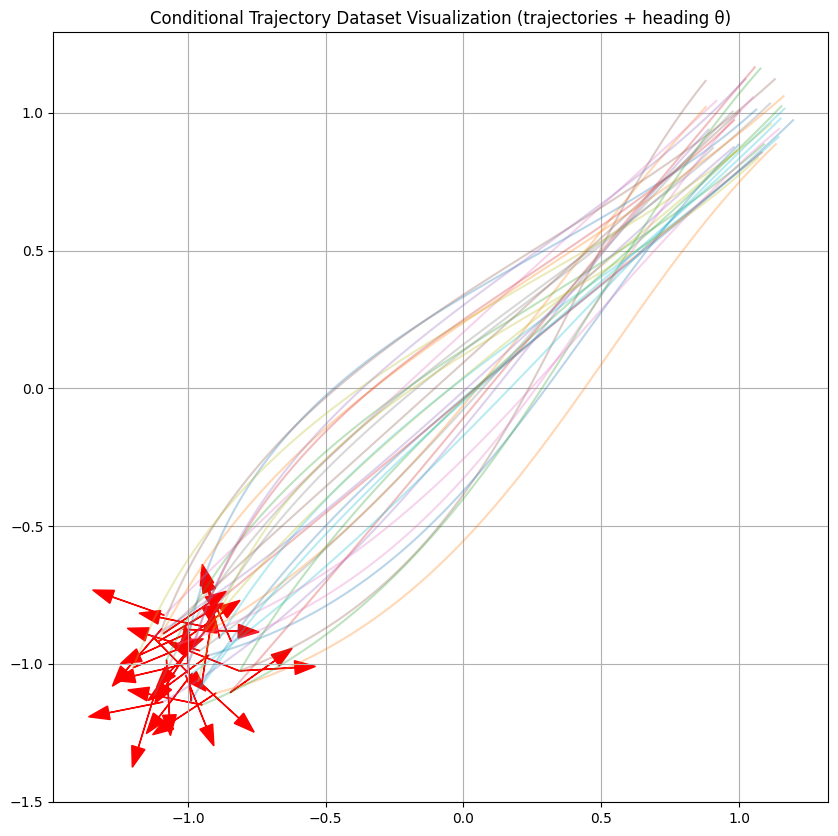

In [26]:
visualize_conditional_dataset(trajectories, thetas, num_display=30)


In [ ]:
# def query_local_velocity_from_unet(
#     model,
#     x_self: torch.Tensor,      # (2,)
#     t_scalar: float,
#     N_train: int = 100,
#     device: str = "cpu",
# ):
#     x_self = x_self.to(device)
#     x_repeat = x_self.view(2, 1).repeat(1, N_train)   # (2, N)
#     x_in = x_repeat.unsqueeze(0)                      # (1, 2, N)

#     t = torch.tensor([t_scalar], dtype=torch.float32, device=device)  # (1,)

#     v_all = model(x_in, t)      # 以前无条件版
#     v_nom = v_all[0, :, -1]
#     return v_nom


In [27]:
def query_local_velocity_from_unet(
    model,
    x_self: torch.Tensor,
    t_scalar: float,
    theta_cond: float,
    N_train: int = 100,
    device: str = "cpu",
):
    x_self = x_self.to(device)

    # 构造“伪轨迹”：把当前点复制 N_train 次
    x_repeat = x_self.view(2, 1).repeat(1, N_train)  # (2, N)
    x_in = x_repeat.unsqueeze(0)                     # (1, 2, N)

    # 时间 t
    t = torch.tensor([t_scalar], dtype=torch.float32, device=device)  # (1,)

    # 条件角度 cond: (1,1)
    theta = torch.tensor([[theta_cond]], dtype=torch.float32, device=device)  # (1,1)

    # 调用条件版 UNet：注意现在要传 cond=theta
    v_all = model(
        x=x_in,
        t=t,
        cond=theta          # ⭐ 条件角度
    )                       # v_all: (1,2,N)

    v_nom = v_all[0, :, -1]  # 取最后一个时间步的速度
    return v_nom


In [18]:
import torch
import math

def generate_traj_batch(batch_size, T, device="cpu"):
    # 随机生成 batch_size 条轨迹，其中一半上弧，一半下弧
    half = batch_size // 2
    
    # s: (T,)
    s = torch.linspace(0., 1., T).to(device)
    
    # cond: (B,)  一半 +1, 一半 -1
    cond = torch.cat([
        torch.ones(half),
        -torch.ones(batch_size - half)
    ]).to(device)  # (B,)
    
    # 扩展成 (B, T)
    s_batch = s.unsqueeze(0).repeat(batch_size, 1)      # (B, T)
    cond_batch = cond.unsqueeze(1).repeat(1, T)         # (B, T)
    
    # 计算轨迹
    x = s_batch                                         # (B, T)
    y = cond_batch * 0.5 * torch.sin(math.pi * s_batch) # (B, T)
    
    # 拼成 (B, 2, T)
    traj = torch.stack([x, y], dim=1)                   # (B, 2, T)
    
    return traj, cond   # traj: (B,2,T), cond: (B,)


In [28]:
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 用你刚刚生成好的 trajectories: (num_traj, 2, 100)
dataset = TrajectoryDataset(trajectories)
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print("✅ DataLoader 准备完成")


✅ DataLoader 准备完成


In [43]:
import numpy as np
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ====== 1) 加载你训练好的 UNet 模型 ======
# 按照你训练时的参数来：time_emb_dim=64, hidden_dim=128, cond_dim=0（无条件）
model = SimpleUNet1D(64, 128, 0).to(device)

ckpt = torch.load("checkpoints/fm_unet_bezier.pth", map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()


# ====== 2) query_local_velocity_from_unet 函数（先用无条件版本） ======
@torch.no_grad()
def query_local_velocity_from_unet(
    model,
    x_self: torch.Tensor,      # (2,) 当前 A 车世界坐标
    t_scalar: float,           # [0, 1] 的“流时间”，看作 A 车在整体轨迹中的位置
    N_train: int = 100,
    device: str = "cpu",
):
    """
    用已经训练好的 UNet-1D，在“伪轨迹”上查询当前点附近的速度。
    思路：把当前点复制成长度 N_train 的轨迹 -> (1, 2, N_train)，
         再加上 t 的 embedding，送进模型，最后取末端时间步的速度。
    """
    # 保证在正确设备上
    x_self = x_self.to(device)  # (2,)

    # 1) 构造伪轨迹: (1, 2, N_train)
    #    (2,) -> (1,2,1) -> (1,2,N_train)
    x_in = x_self.view(1, 2, 1).repeat(1, 1, N_train)  # (1,2,N_train)

    # 2) 构造时间输入 t: (1,)
    t_tensor = torch.tensor([t_scalar], dtype=torch.float32, device=device)  # (1,)

    # 3) 调用模型（无条件：只传 x 和 t）
    v_pred = model(x_in, t_tensor)      # 期望输出: (1, 2, N_train)

    # 4) 取最后一个时间步的速度作为“局部速度”
    v_local = v_pred[0, :, -1]          # (2,)

    return v_local                      # torch.Tensor(2,)


Using device: cuda


In [44]:
import numpy as np
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ====== 1) 加载你训练好的 UNet 模型 ======
# 根据你自己的类名 & 路径改
   # 举例
model = SimpleUNet1D(64, 128, 0).to(device)

ckpt = torch.load("checkpoints/fm_unet_bezier.pth", map_location=device)
model.load_state_dict(ckpt["model"])
model.to(device)
model.eval()


# ====== 2) query_local_velocity_from_unet 函数 ======
@torch.no_grad()
def query_local_velocity_from_unet(
    model,
    x_self: torch.Tensor,      # (2,) 当前 A 车世界坐标
    t_scalar: float,           # [0, 1] 的“流时间”，看作 A 车在整体轨迹中的位置
    N_train: int = 100,
    device: str = "cpu",
    cond_theta: float = None,  # 如果你有角度条件，就传进来；没有可以忽略
):
    """
    用已经训练好的 UNet-1D，在“伪轨迹”上查询当前点附近的速度。
    思路：把当前点复制成长度 N_train 的轨迹 -> (1, 2, N_train)，
         再加上 t 的 embedding / cond，送进模型，最后取末端时间步的速度。
    """
    x_self = x_self.to(device)  # (2,)

    # 1) 构造伪轨迹: (1,2,N_train)
    x_repeat = x_self.view(2, 1).repeat(1, N_train)  # (2,N_train)
    x_in = x_repeat.unsqueeze(0)                     # (1,2,N_train)

    # 2) 构造 t 条件 (根据你模型的接口调整)
    t_tensor = torch.tensor([t_scalar], dtype=torch.float32, device=device)  # (1,)

    if cond_theta is not None:
        theta_tensor = torch.tensor([cond_theta], dtype=torch.float32, device=device)  # (1,)
        v_pred = model(x_in, t_tensor, theta_tensor)  # 例如接口: model(x, t, theta)
    else:
        v_pred = model(x_in, t_tensor)                # 例如接口: model(x, t)

    # 3) 取最后一个时间步的速度作为“局部速度”
    #    v_pred: (1,2,N_train) or (1,2,N_train,?) 按你模型shape调整
    v_local = v_pred[0, :, -1]     # (2,)

    return v_local                 # torch.Tensor (2,)


Using device: cuda


In [66]:
# ===============================================================
# 第四阶段: 构造一个“伪”B_history（从 A 轨迹生成）
# ===============================================================

def build_fake_B_history_from_A(traj_batch: torch.Tensor, T_hist: int = 8) -> torch.Tensor:
    """
    用当前 batch 的 A 轨迹，构造一个假的 B_history:
      输入 traj_batch: (B, 2, T_traj)  -> [x_A, y_A]
      输出 B_history:  (B, T_hist, 4)  -> [x_B, y_B, vx_B, vy_B]
    
    这里简单地取前 T_hist 个点作为 B 的 position，再用差分近似 velocity。
    只是为了让 SceneEncoder 和 conditional FM 先跑通。
    """
    # 取前 T_hist 帧的位置 (B, 2, T_hist)
    pos = traj_batch[:, :, :T_hist]                      # (B, 2, T_hist)
    pos = pos.permute(0, 2, 1)                           # (B, T_hist, 2)

    # 用差分近似速度
    vel = pos[:, 1:, :] - pos[:, :-1, :]                 # (B, T_hist-1, 2)
    # 补一帧，让长度对齐 T_hist
    last_vel = vel[:, -1:, :]                            # (B, 1, 2)
    vel = torch.cat([vel, last_vel], dim=1)              # (B, T_hist, 2)

    # 拼接 -> (B, T_hist, 4)
    B_history = torch.cat([pos, vel], dim=-1)
    return B_history


In [45]:
# 小测试：在某个位置上问一问 UNet 给的速度
test_x = torch.tensor([-1.0, -1.0], dtype=torch.float32, device=device)
v_test = query_local_velocity_from_unet(
    model, 
    test_x, 
    t_scalar=0.3, 
    N_train=100, 
    device=device,
    cond_theta=None,        # 你现在是无条件模型，先传 None
)
print("v_test shape:", v_test.shape)
print("v_test:", v_test)


v_test shape: torch.Size([2])
v_test: tensor([0.4322, 0.0205], device='cuda:0')


In [48]:
import numpy as np

# 仿真参数
dt = 0.05          # 步长
T_sim = 8.0        # 总时间
N_steps = int(T_sim / dt)

# A / B 车的初始位置 & 目标
xA_0 = np.array([-1.0, -1.0], dtype=np.float32)
xB_0 = np.array([-1.0,  1.0], dtype=np.float32)

goal_A = np.array([1.0, 1.0], dtype=np.float32)
goal_B = np.array([1.0, -1.0], dtype=np.float32)

safe_radius = 0.3   # 碰撞安全半径
v_max = 0.5         # A 车最大速度

def simple_goal_controller(x, goal, v_max=0.4):
    """
    一个给 B 车用的简单 controller：朝着 goal 走。
    """
    direction = goal - x
    dist = np.linalg.norm(direction)
    if dist < 1e-6:
        return np.zeros(2, dtype=np.float32)
    v = direction / dist * min(v_max, dist)
    return v.astype(np.float32)


In [52]:
# ===============================================================
# CBF 投影（世界坐标）：整条轨迹版本 + 单步 wrapper
# ===============================================================

@torch.no_grad()
def cbf_project_velocity_world(
    x_1x2N: torch.Tensor,
    v_nom_1x2N: torch.Tensor,
    ellipses,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 5,
    # ★ 两车互相避障相关
    other_agent_traj: torch.Tensor = None,   # 允许形状 (1,2,N) 或 (2,N)
    agent_safe_radius: float = 0.5,
    # ★ 压强 + α(h) 参数
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    CBF 投影（世界坐标，整条轨迹版本）：
      - 对静态椭圆障碍 + 另一辆车，都加 CBF 约束
      - α(h) = γ(x) * h，其中 γ(x) = γ_min + w_p * P(x)，压强 P(x)=k/d^n

    输入:
      - x_1x2N:      (1,2,N) 当前整条轨迹（A 车位置）
      - v_nom_1x2N:  (1,2,N) 名义速度场（FM 输出）
      - ellipses:    障碍物列表（可以为 [] 或 None）
      - other_agent_traj:
            - (1,2,N) 或 (2,N)，另一辆车的整条轨迹（B 车）
    输出:
      - v_safe_1x2N: (1,2,N) 投影后的安全速度
    """
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)
    has_other = other_agent_traj is not None

    # 如果既没有障碍又没有对车，那就不用 CBF
    if (not has_ellipses) and (not has_other):
        return v_nom_1x2N

    # 允许 x_1x2N 传入 (2,N)，统一成 (1,2,N)
    if x_1x2N.dim() == 2:
        x_1x2N = x_1x2N.unsqueeze(0)
    B, D, N = x_1x2N.shape
    assert D == 2, "x_1x2N 的 shape 必须是 (B,2,N) 或 (2,N)"

    # v_nom 同样统一维度
    if v_nom_1x2N.dim() == 2:
        v_nom_1x2N = v_nom_1x2N.unsqueeze(0)

    # 为了简单，我们目前只支持 B=1 的单条轨迹
    assert B == 1, "当前实现假定 batch=1（单条轨迹），如果需要批量可再扩展"

    x_world_2N = x_1x2N.squeeze(0)  # (2,N)
    v_now = v_nom_1x2N.squeeze(0)   # (2,N)

    # ============================================================
    # 1) 计算两车之间的压强 P(x)
    # ============================================================
    if has_other:
        # 支持 (1,2,N) 或 (2,N)
        if other_agent_traj.dim() == 3:
            x_other_2N = other_agent_traj.squeeze(0)  # (2,N)
        elif other_agent_traj.dim() == 2:
            x_other_2N = other_agent_traj             # (2,N)
        else:
            raise ValueError("other_agent_traj 形状必须是 (1,2,N) 或 (2,N)")

        # delta_agent: (N,2) = x_A - x_B
        delta_agent = x_world_2N.transpose(0, 1) - x_other_2N.transpose(0, 1)  # (N,2)
        dist = torch.norm(delta_agent, dim=1).clamp_min(1e-3)                  # (N,)
        P = press_k / dist.pow(press_n)                                        # (N,)
    else:
        delta_agent = None
        dist = None
        P = torch.zeros(N, device=x_world_2N.device)

    # γ(x) = γ_min + w_p * P
    gamma_x = gamma_min + w_p * P  # (N,)

    # ============================================================
    # 2) CBF 投影主循环（多次迭代 refine）
    # ============================================================
    for _ in range(max(1, passes)):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (N,2)

        # ---------- (a) 静态椭圆障碍 CBF ----------
        if has_ellipses:
            for e in ellipses:
                # 你之前定义好的函数：ellipse_h_grad_batch(x, e)
                # 返回:
                #   h_e:   (N,)
                #   grad_w:(N,2)
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)
                h_eff = h_e - float(extra_margin)          # 安全 margin

                # α(h) = γ(x) * h
                alpha_h = gamma_x * h_eff                  # (N,)

                # CBF: ∇h·v + α(h) ≥ 0
                s_e = (grad_w * v_T).sum(dim=1) + alpha_h  # (N,)

                all_s.append(s_e)
                all_a.append(grad_w)

        # ---------- (b) 两车之间的 CBF ----------
        if has_other:
            # 注意：delta_agent 和 dist 在上面已经算过
            # h_agent(x) = ||x - x_other||^2 - R_safe^2
            h_agent = dist**2 - agent_safe_radius**2      # (N,)
            grad_agent = 2.0 * delta_agent                # (N,2)

            alpha_h_agent = gamma_x * h_agent             # (N,)
            s_agent = (grad_agent * v_T).sum(dim=1) + alpha_h_agent

            all_s.append(s_agent)
            all_a.append(grad_agent)

        if len(all_s) == 0:
            # 没有任何约束
            break

        S_cat = torch.stack(all_s, dim=0)          # (E,N)
        s_min, idx_min = torch.min(S_cat, dim=0)   # (N,)

        A_cat = torch.stack(all_a, dim=0)          # (E,N,2)
        a_pick = A_cat.gather(
            0,
            idx_min.view(1, -1, 1).expand(1, S_cat.size(1), 2)
        ).squeeze(0)  # (N,2)

        # ---------- 只修正违反约束的点 ----------
        mask = (s_min < 0.0)
        if mask.any():
            a_sq = (a_pick ** 2).sum(dim=1).clamp_min(1e-12)
            coef = torch.zeros_like(s_min)
            coef[mask] = -s_min[mask] / a_sq[mask]     # λ = -s / ||a||^2

            delta = (coef.view(1, -1) * a_pick.transpose(0, 1))  # (2,N)

            if max_corr_norm > 0:
                dnorm = delta.norm(dim=0).clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale

            v_now = v_now + delta

    return v_now.unsqueeze(0)  # (1,2,N)


# ===============================================================
# 单步版本 wrapper：方便在 rollout 的 for k in range(T) 里调用
# ===============================================================

@torch.no_grad()
def cbf_project_velocity_step(
    x_now_2: torch.Tensor,          # (2,)  当前 A 车位置
    v_nom_2: torch.Tensor,          # (2,)  名义速度
    ellipses,
    other_agent_pos_2: torch.Tensor = None,  # (2,) 当前 B 车位置
    agent_safe_radius: float = 0.5,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    单步 CBF 投影，专为在线仿真准备：
      输入单个时刻的 x_A, v_nom, x_B
      内部自动扩展成 (1,2,1)，调用上面的 cbf_project_velocity_world。
    """
    device = x_now_2.device
    x_traj = x_now_2.view(1, 2, 1)      # (1,2,1)
    v_traj = v_nom_2.view(1, 2, 1)      # (1,2,1)

    if other_agent_pos_2 is not None:
        other_traj = other_agent_pos_2.view(1, 2, 1)   # (1,2,1)
    else:
        other_traj = None

    v_safe_traj = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses,
        extra_margin=extra_margin,
        max_corr_norm=max_corr_norm,
        passes=5,
        other_agent_traj=other_traj,
        agent_safe_radius=agent_safe_radius,
        gamma_min=gamma_min,
        w_p=w_p,
        press_k=press_k,
        press_n=press_n,
    )  # (1,2,1)

    v_safe_2 = v_safe_traj.squeeze(0).squeeze(-1)  # (2,)
    return v_safe_2


In [53]:
def mpc_step_A_with_my_cbf(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    ellipses=None,              # 你的静态椭圆障碍列表；如果没有就传 None
):
    """
    单步：
      1) B 车用 simple_goal_controller（你可以之后替换）
      2) A 车用 UNet 查询名义速度 vA_nom
      3) 用你自己的 CBF 投影函数 cbf_project_velocity_step 做投影
      4) 更新 xA, xB
    """

    # 1) B 车速度（先继续用简单直线控制）
    vB = simple_goal_controller(xB, goal_B, v_max=0.4)

    # 2) UNet 查询 A 车名义速度 vA_nom
    xA_tensor = torch.tensor(xA, dtype=torch.float32, device=device)
    vA_nom_tensor = query_local_velocity_from_unet(
        model,
        xA_tensor,
        t_scalar=t_norm,
        N_train=100,
        device=device,
        cond_theta=None,     # 现在用的是无条件模型
    )                        # (2,)
    
    # 3) 用你自己的 CBF 做单步投影
    xA_t = xA_tensor                          # (2,)
    v_nom_t = vA_nom_tensor                   # (2,)
    xB_t = torch.tensor(xB, dtype=torch.float32, device=device)  # (2,)

    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_t,
        v_nom_2=v_nom_t,
        ellipses=ellipses,                    # 如果没有静态障碍，传 None 或 []
        other_agent_pos_2=xB_t,               # 把 B 车当成“动态圆障碍”
        agent_safe_radius=0.5,                # 你自己的参数
        extra_margin=0.0,                     # 看你想不想再扩一点
        max_corr_norm=2.0,
        gamma_min=1.0,
        w_p=5.0,
        press_k=1.0,
        press_n=2.0,
    )                                         # (2,)

    vA_safe = vA_safe_tensor.detach().cpu().numpy()   # 转成 numpy 给积分用

    # 4) 欧拉更新
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB * dt

    return xA_next, xB_next, vA_safe, vB


In [ ]:
xs_A = [xA_0.copy()]
xs_B = [xB_0.copy()]

xA = xA_0.copy()
xB = xB_0.copy()


#MPC rollout
for k in range(N_steps):
    t_norm = k / max(1, N_steps - 1)

    xA, xB, vA_safe, vB = mpc_step_A_with_my_cbf(
        xA=xA,
        xB=xB,
        t_norm=t_norm,
        model=model,
        ellipses=None,      # 暂时先不加静态椭圆障碍，有的话在这里传进去
    )

    xs_A.append(xA.copy())
    xs_B.append(xB.copy())


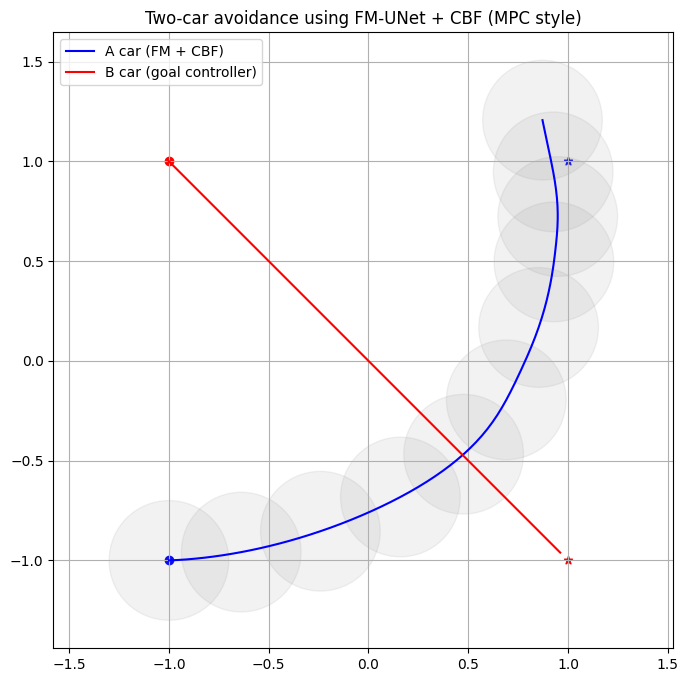

In [55]:
xs_A = np.stack(xs_A, axis=0)  # (N_steps+1, 2)
xs_B = np.stack(xs_B, axis=0)

# 画图
plt.figure(figsize=(8, 8))
plt.plot(xs_A[:, 0], xs_A[:, 1], 'b-', label='A car (FM + CBF)')
plt.plot(xs_B[:, 0], xs_B[:, 1], 'r-', label='B car (goal controller)')

# 起点 & 终点
plt.scatter(xA_0[0], xA_0[1], c='b', marker='o')
plt.scatter(goal_A[0], goal_A[1], c='b', marker='*')

plt.scatter(xB_0[0], xB_0[1], c='r', marker='o')
plt.scatter(goal_B[0], goal_B[1], c='r', marker='*')

# 画几个时间点的安全圈
for i in range(0, len(xs_A), max(1, len(xs_A)//10)):
    circle = plt.Circle(xs_A[i], safe_radius, color='gray', alpha=0.1)
    plt.gca().add_patch(circle)

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Two-car avoidance using FM-UNet + CBF (MPC style)")
plt.show()

In [56]:
@torch.no_grad()
def fm_controller_for_B(xB: np.ndarray, t_norm: float, model, device):
    """
    用 Flow Matching UNet 给 B 车产生名义速度（不加 CBF）。
    """
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)
    vB_nom = query_local_velocity_from_unet(
        model,
        x_self=xB_tensor,
        t_scalar=t_norm,
        N_train=100,
        device=device,
        cond_theta=None,     # 现在模型是无条件的
    )                       # (2,)
    vB = vB_nom.detach().cpu().numpy()
    
    # 可以像之前一样限幅一下速度
    v_norm = np.linalg.norm(vB)
    v_max_B = 0.4
    if v_norm > v_max_B:
        vB = vB / v_norm * v_max_B
    
    return vB.astype(np.float32)


In [57]:
def mpc_step_A_with_my_cbf(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    ellipses=None,
):
    # 1) B 车：用 Flow Matching 生成名义速度（不加 CBF）
    vB = fm_controller_for_B(xB, t_norm, model, device)

    # 2) A 车：用 Flow Matching 生成名义速度
    xA_tensor = torch.tensor(xA, dtype=torch.float32, device=device)
    vA_nom_tensor = query_local_velocity_from_unet(
        model,
        x_self=xA_tensor,
        t_scalar=t_norm,
        N_train=100,
        device=device,
        cond_theta=None,
    )

    # 3) A 车：用你自己的 CBF 投影
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)
    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,
        other_agent_pos_2=xB_tensor,
        agent_safe_radius=0.5,
        extra_margin=0.0,
        max_corr_norm=2.0,
        gamma_min=1.0,
        w_p=5.0,
        press_k=1.0,
        press_n=2.0,
    )

    vA_safe = vA_safe_tensor.detach().cpu().numpy()

    # 4) 欧拉更新
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB * dt

    return xA_next, xB_next, vA_safe, vB


In [58]:
xA = xA_0.copy()
xB = xB_0.copy()
xs_A = [xA.copy()]
xs_B = [xB.copy()]

for k in range(N_steps):
    t_norm = k / max(1, N_steps - 1)

    xA, xB, vA_safe, vB = mpc_step_A_with_my_cbf(
        xA=xA,
        xB=xB,
        t_norm=t_norm,
        model=model,
        ellipses=None,   # 暂时没静态椭圆障碍就传 None
    )

    xs_A.append(xA.copy())
    xs_B.append(xB.copy())


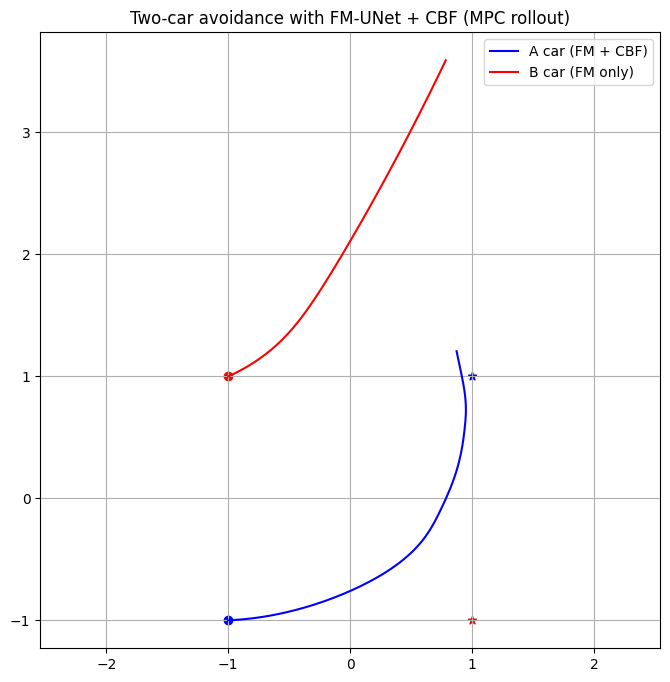

In [62]:
# rollout 完成后一定要加这两行！
xs_A = np.stack(xs_A, axis=0)  # (N_steps+1, 2)
xs_B = np.stack(xs_B, axis=0)

plt.figure(figsize=(8, 8))

plt.plot(xs_A[:, 0], xs_A[:, 1], 'b-', label='A car (FM + CBF)')
plt.plot(xs_B[:, 0], xs_B[:, 1], 'r-', label='B car (FM only)')

plt.scatter(xA_0[0], xA_0[1], c='b', marker='o')
plt.scatter(goal_A[0], goal_A[1], c='b', marker='*')

plt.scatter(xB_0[0], xB_0[1], c='r', marker='o')
plt.scatter(goal_B[0], goal_B[1], c='r', marker='*')

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Two-car avoidance with FM-UNet + CBF (MPC rollout)")
plt.show()


In [63]:
def mpc_step_A_with_my_cbf(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    ellipses=None,
):
    # 1) B 车：用 Flow Matching 生成名义速度（不加 CBF）
    vB = fm_controller_for_B(xB, t_norm, model, device)

    # 2) A 车：用 Flow Matching 生成名义速度
    xA_tensor = torch.tensor(xA, dtype=torch.float32, device=device)
    vA_nom_tensor = make_goal_pulled_v_nom(
    xA_tensor,
    t_norm,
    model,
    goal_A=goal_A,
    kg=0.8,   # “towards goal”的强度，可以调
    lam=0.3,  # FM vs goal 的权重
)

    # 3) A 车：用你自己的 CBF 投影
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)
    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,
        other_agent_pos_2=xB_tensor,
        agent_safe_radius=0.5,
        extra_margin=0.0,
        max_corr_norm=2.0,
        gamma_min=1.0,
        w_p=5.0,
        press_k=1.0,
        press_n=2.0,
    )

    vA_safe = vA_safe_tensor.detach().cpu().numpy()

    # 4) 欧拉更新
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB * dt

    return xA_next, xB_next, vA_safe, vB


In [64]:
def make_goal_pulled_v_nom(xA_tensor, t_norm, model, goal_A, kg=0.5, lam=0.3):
    # 1) Flow Matching 名义速度
    v_fm = query_local_velocity_from_unet(
        model=model,
        x_self=xA_tensor,
        t_scalar=t_norm,
        N_train=100,
        device=device,
        cond_theta=None,
    )  # (2,)

    # 2) 朝 goal 的速度
    xA_np = xA_tensor.detach().cpu().numpy()
    dir_goal = goal_A - xA_np
    dist_goal = np.linalg.norm(dir_goal)
    if dist_goal < 1e-6:
        v_goal_np = np.zeros(2, dtype=np.float32)
    else:
        v_goal_np = kg * dir_goal / dist_goal

    v_goal = torch.tensor(v_goal_np, dtype=torch.float32, device=device)

    # 3) 线性组合
    v_nom = (1.0 - lam) * v_fm + lam * v_goal
    return v_nom


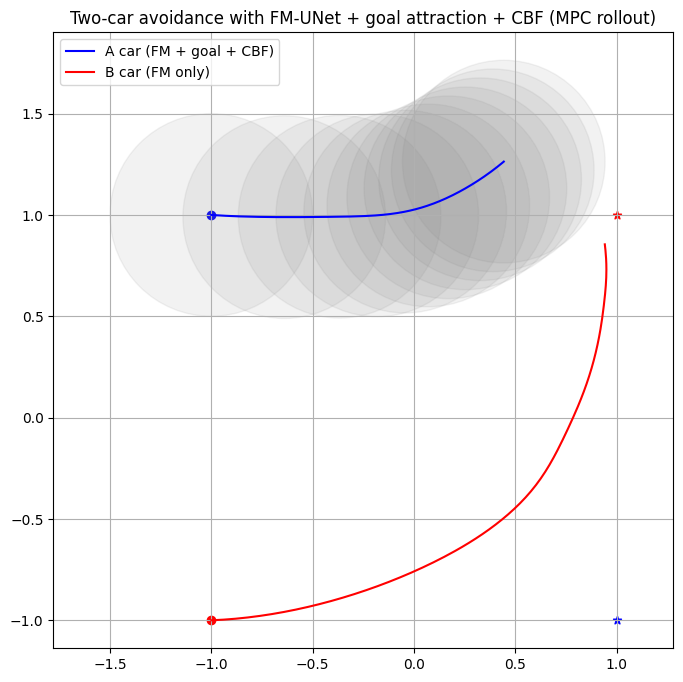

In [66]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ========= 假定这些变量你前面已经有了 =========
# model: 训练好的 SimpleUNet1D
# device: "cuda" 或 "cpu"
dt = 0.05
T_sim = 8.0
N_steps = int(T_sim / dt)

xA_0 = np.array([-1.0, 1.0], dtype=np.float32)
xB_0 = np.array([-1.0,  -1.0], dtype=np.float32)
goal_A = np.array([1.0,  -1.0], dtype=np.float32)
goal_B = np.array([1.0, 1.0], dtype=np.float32)

safe_radius = 0.5   # 你在 CBF 里用的 agent_safe_radius

# ========= 1) 让 v_nom 同时考虑 FM 和 goal 吸引 =========
@torch.no_grad()
def make_goal_pulled_v_nom(
    xA_tensor: torch.Tensor,
    t_norm: float,
    model,
    goal_A: np.ndarray,
    kg: float = 0.8,   # 朝 goal 的力度
    lam: float = 0.3,  # goal 在 v_nom 里的权重 [0,1]
):
    """
    v_nom = (1 - lam) * v_FM + lam * v_goal
    """
    # 1) Flow Matching 的名义速度
    v_fm = query_local_velocity_from_unet(
        model=model,
        x_self=xA_tensor,
        t_scalar=t_norm,
        N_train=100,
        device=device,
        cond_theta=None,
    )   # (2,)

    # 2) 朝 goal 的速度（单位方向 * kg）
    xA_np = xA_tensor.detach().cpu().numpy()
    dir_goal = goal_A - xA_np
    dist_goal = np.linalg.norm(dir_goal)
    if dist_goal < 1e-6:
        v_goal_np = np.zeros(2, dtype=np.float32)
    else:
        v_goal_np = kg * dir_goal / dist_goal

    v_goal = torch.tensor(v_goal_np, dtype=torch.float32, device=device)

    # 3) 线性组合
    v_nom = (1.0 - lam) * v_fm + lam * v_goal
    return v_nom


# ========= 2) B 车：FM 控制器（不加 CBF，只限幅） =========
@torch.no_grad()
def fm_controller_for_B(xB: np.ndarray, t_norm: float, model, device, v_max_B=0.4):
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)
    vB_nom = query_local_velocity_from_unet(
        model=model,
        x_self=xB_tensor,
        t_scalar=t_norm,
        N_train=100,
        device=device,
        cond_theta=None,
    )
    vB = vB_nom.detach().cpu().numpy()
    v_norm = np.linalg.norm(vB)
    if v_norm > v_max_B:
        vB = vB / v_norm * v_max_B
    return vB.astype(np.float32)


# ========= 3) 单步 MPC：A 用 v_nom(FM+goal) + 你的 CBF，B 用 FM =========
def mpc_step_A_goal_cbf(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    ellipses=None,
):
    # --- B 车：FM 控制 ---
    vB = fm_controller_for_B(xB, t_norm, model, device)

    # --- A 车：v_nom = FM + goal 吸引 ---
    xA_tensor = torch.tensor(xA, dtype=torch.float32, device=device)
    vA_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xA_tensor,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        kg=0.8,
        lam=0.3,
    )

    # --- A 车：CBF 投影 ---
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)
    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,
        other_agent_pos_2=xB_tensor,
        agent_safe_radius=safe_radius,
        extra_margin=0.0,
        max_corr_norm=2.0,
        gamma_min=1.0,
        w_p=5.0,
        press_k=1.0,
        press_n=2.0,
    )

    vA_safe = vA_safe_tensor.detach().cpu().numpy()

    # --- 欧拉更新 ---
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB * dt

    return xA_next, xB_next, vA_safe, vB


# ========= 4) MPC rollout =========
xA = xA_0.copy()
xB = xB_0.copy()

xs_A = [xA.copy()]
xs_B = [xB.copy()]
vs_A = []
vs_B = []

for k in range(N_steps):
    t_norm = k / max(1, N_steps - 1)

    xA, xB, vA_safe, vB = mpc_step_A_goal_cbf(
        xA=xA,
        xB=xB,
        t_norm=t_norm,
        model=model,
        ellipses=None,   # 如有静态椭圆障碍，在这里传入
    )

    xs_A.append(xA.copy())
    xs_B.append(xB.copy())
    vs_A.append(vA_safe.copy())
    vs_B.append(vB.copy())

xs_A = np.stack(xs_A, axis=0)  # (N_steps+1, 2)
xs_B = np.stack(xs_B, axis=0)

# ========= 5) 画图 =========
plt.figure(figsize=(8, 8))

plt.plot(xs_A[:, 0], xs_A[:, 1], 'b-', label='A car (FM + goal + CBF)')
plt.plot(xs_B[:, 0], xs_B[:, 1], 'r-', label='B car (FM only)')

plt.scatter(xA_0[0], xA_0[1], c='b', marker='o')
plt.scatter(goal_A[0], goal_A[1], c='b', marker='*')

plt.scatter(xB_0[0], xB_0[1], c='r', marker='o')
plt.scatter(goal_B[0], goal_B[1], c='r', marker='*')

# A 车的安全圈
for i in range(0, len(xs_A), max(1, len(xs_A)//10)):
    circle = plt.Circle(xs_A[i], safe_radius, color='gray', alpha=0.1)
    plt.gca().add_patch(circle)

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Two-car avoidance with FM-UNet + goal attraction + CBF (MPC rollout)")
plt.show()


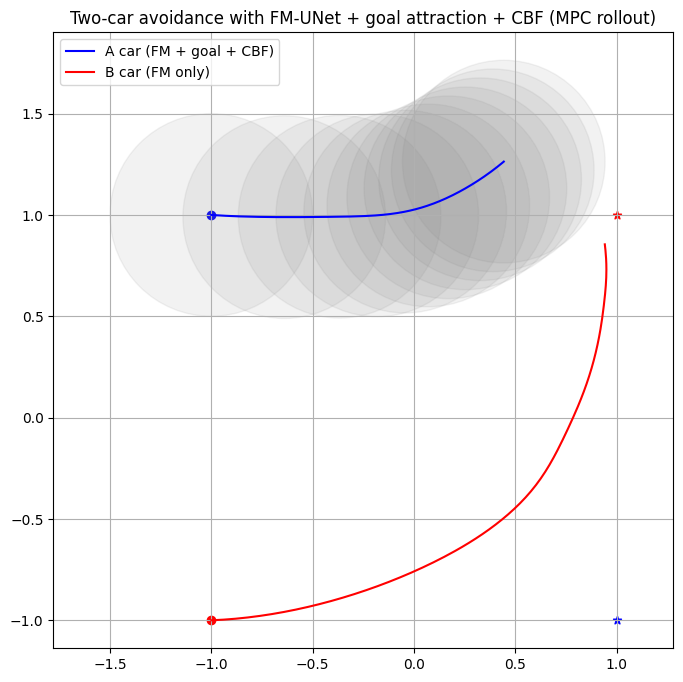

In [67]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ========= 假定这些变量你前面已经有了 =========
# model: 训练好的 SimpleUNet1D
# device: "cuda" 或 "cpu"
dt = 0.05
T_sim = 8.0
N_steps = int(T_sim / dt)

xA_0 = np.array([-1.0, 1.0], dtype=np.float32)
xB_0 = np.array([-1.0,  -1.0], dtype=np.float32)
goal_A = np.array([1.0,  -1.0], dtype=np.float32)
goal_B = np.array([1.0, 1.0], dtype=np.float32)

safe_radius = 0.5   # 你在 CBF 里用的 agent_safe_radius

# ========= 1) 让 v_nom 同时考虑 FM 和 goal 吸引 =========
@torch.no_grad()
def make_goal_pulled_v_nom(
    xA_tensor: torch.Tensor,
    t_norm: float,
    model,
    goal_A: np.ndarray,
    kg: float = 1.5,   # 朝 goal 的力度
    lam: float = 0.5,  # goal 在 v_nom 里的权重 [0,1]
):
    """
    v_nom = (1 - lam) * v_FM + lam * v_goal
    """
    # 1) Flow Matching 的名义速度
    v_fm = query_local_velocity_from_unet(
        model=model,
        x_self=xA_tensor,
        t_scalar=t_norm,
        N_train=100,
        device=device,
        cond_theta=None,
    )   # (2,)

    # 2) 朝 goal 的速度（单位方向 * kg）
    xA_np = xA_tensor.detach().cpu().numpy()
    dir_goal = goal_A - xA_np
    dist_goal = np.linalg.norm(dir_goal)
    if dist_goal < 1e-6:
        v_goal_np = np.zeros(2, dtype=np.float32)
    else:
        v_goal_np = kg * dir_goal / dist_goal

    v_goal = torch.tensor(v_goal_np, dtype=torch.float32, device=device)

    # 3) 线性组合
    v_nom = (1.0 - lam) * v_fm + lam * v_goal
    return v_nom


# ========= 2) B 车：FM 控制器（不加 CBF，只限幅） =========
@torch.no_grad()
def fm_controller_for_B(xB: np.ndarray, t_norm: float, model, device, v_max_B=0.4):
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)
    vB_nom = query_local_velocity_from_unet(
        model=model,
        x_self=xB_tensor,
        t_scalar=t_norm,
        N_train=100,
        device=device,
        cond_theta=None,
    )
    vB = vB_nom.detach().cpu().numpy()
    v_norm = np.linalg.norm(vB)
    if v_norm > v_max_B:
        vB = vB / v_norm * v_max_B
    return vB.astype(np.float32)


# ========= 3) 单步 MPC：A 用 v_nom(FM+goal) + 你的 CBF，B 用 FM =========
def mpc_step_A_goal_cbf(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    ellipses=None,
):
    # --- B 车：FM 控制 ---
    vB = fm_controller_for_B(xB, t_norm, model, device)

    # --- A 车：v_nom = FM + goal 吸引 ---
    xA_tensor = torch.tensor(xA, dtype=torch.float32, device=device)
    vA_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xA_tensor,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        kg=0.8,
        lam=0.3,
    )

    # --- A 车：CBF 投影 ---
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)
    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,
        other_agent_pos_2=xB_tensor,
        agent_safe_radius=safe_radius,
        extra_margin=0.0,
        max_corr_norm=2.0,
        gamma_min=1.0,
        w_p=1.0,
        press_k=1.0,
        press_n=2.0,
    )

    vA_safe = vA_safe_tensor.detach().cpu().numpy()

    # --- 欧拉更新 ---
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB * dt

    return xA_next, xB_next, vA_safe, vB


# ========= 4) MPC rollout =========
xA = xA_0.copy()
xB = xB_0.copy()

xs_A = [xA.copy()]
xs_B = [xB.copy()]
vs_A = []
vs_B = []

for k in range(N_steps):
    t_norm = k / max(1, N_steps - 1)

    xA, xB, vA_safe, vB = mpc_step_A_goal_cbf(
        xA=xA,
        xB=xB,
        t_norm=t_norm,
        model=model,
        ellipses=None,   # 如有静态椭圆障碍，在这里传入
    )

    xs_A.append(xA.copy())
    xs_B.append(xB.copy())
    vs_A.append(vA_safe.copy())
    vs_B.append(vB.copy())

xs_A = np.stack(xs_A, axis=0)  # (N_steps+1, 2)
xs_B = np.stack(xs_B, axis=0)

# ========= 5) 画图 =========
plt.figure(figsize=(8, 8))

plt.plot(xs_A[:, 0], xs_A[:, 1], 'b-', label='A car (FM + goal + CBF)')
plt.plot(xs_B[:, 0], xs_B[:, 1], 'r-', label='B car (FM only)')

plt.scatter(xA_0[0], xA_0[1], c='b', marker='o')
plt.scatter(goal_A[0], goal_A[1], c='b', marker='*')

plt.scatter(xB_0[0], xB_0[1], c='r', marker='o')
plt.scatter(goal_B[0], goal_B[1], c='r', marker='*')

# A 车的安全圈
for i in range(0, len(xs_A), max(1, len(xs_A)//10)):
    circle = plt.Circle(xs_A[i], safe_radius, color='gray', alpha=0.1)
    plt.gca().add_patch(circle)

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Two-car avoidance with FM-UNet + goal attraction + CBF (MPC rollout)")
plt.show()


In [75]:
import numpy as np
import torch
import math

device = "cuda" if torch.cuda.is_available() else "cpu"

# ===== wrap & angle-condition =====

def wrap_to_pi(angle: torch.Tensor) -> torch.Tensor:
    return (angle + math.pi) % (2 * math.pi) - math.pi

def compute_angle_condition(x_self, x_other, x_goal, device=None):
    """
    x_self, x_other, x_goal: (2,)  可以是 np 或 torch
    返回 cond ∈ {+1.0, -1.0}
    """
    if device is None:
        if isinstance(x_self, torch.Tensor):
            device = x_self.device
        else:
            device = "cpu"

    x_self  = torch.as_tensor(x_self,  dtype=torch.float32, device=device).view(2)
    x_other = torch.as_tensor(x_other, dtype=torch.float32, device=device).view(2)
    x_goal  = torch.as_tensor(x_goal,  dtype=torch.float32, device=device).view(2)

    vec_goal   = x_goal  - x_self
    vec_other  = x_other - x_self

    theta_goal  = torch.atan2(vec_goal[1],  vec_goal[0])
    theta_other = torch.atan2(vec_other[1], vec_other[0])

    theta_rel = wrap_to_pi(theta_goal - theta_other)
    cond = 1.0 if theta_rel.item() > 0.0 else -1.0
    return cond


In [76]:
@torch.no_grad()
def query_local_velocity_from_unet(
    model,
    x_self: torch.Tensor,      # (2,)
    t_scalar: float,
    theta_cond: float,         # ⭐ 角度条件
    N_train: int = 100,
    device: str = "cpu",
):
    x_self = x_self.to(device)

    # 伪轨迹 (1,2,N_train)
    x_in = x_self.view(1, 2, 1).repeat(1, 1, N_train)

    # 时间 (1,)
    t_tensor = torch.tensor([t_scalar], dtype=torch.float32, device=device)

    # 条件 (1,1)
    cond = torch.tensor([[theta_cond]], dtype=torch.float32, device=device)

    v_pred = model(x_in, t_tensor, cond=cond)  # (1,2,N_train)
    v_local = v_pred[0, :, -1]                 # (2,)
    return v_local


In [77]:
@torch.no_grad()
def make_goal_pulled_v_nom(
    xA_tensor: torch.Tensor,   # (2,)
    t_norm: float,
    model,
    goal_A: np.ndarray,
    theta_cond_A: float,       # ⭐ 角度条件
    kg: float = 0.8,
    lam: float = 0.3,
):
    """
    v_nom = (1 - lam) * v_FM(theta_cond) + lam * v_goal
    """
    # 1) 带角度条件的 FM 速度
    v_fm = query_local_velocity_from_unet(
        model=model,
        x_self=xA_tensor,
        t_scalar=t_norm,
        theta_cond=theta_cond_A,   # ⭐ 用上角度
        N_train=100,
        device=device,
    )  # (2,)

    # 2) 朝 goal 的速度
    xA_np = xA_tensor.detach().cpu().numpy()
    dir_goal = goal_A - xA_np
    dist_goal = np.linalg.norm(dir_goal)
    if dist_goal < 1e-6:
        v_goal_np = np.zeros(2, dtype=np.float32)
    else:
        v_goal_np = kg * dir_goal / dist_goal

    v_goal = torch.tensor(v_goal_np, dtype=torch.float32, device=device)

    # 3) 线性组合
    v_nom = (1.0 - lam) * v_fm + lam * v_goal
    return v_nom


In [78]:
def simple_goal_controller(x: np.ndarray, goal: np.ndarray, v_max: float = 0.4):
    dir_vec = goal - x
    dist = np.linalg.norm(dir_vec)
    if dist < 1e-6:
        return np.zeros(2, dtype=np.float32)
    v = dir_vec / dist * v_max
    return v.astype(np.float32)


In [94]:
safe_radius = 0.3   # 你 CBF 里用的 agent_safe_radius

def mpc_step_A_goal_cbf_angle(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    goal_A: np.ndarray,
    goal_B: np.ndarray,
    ellipses=None,
):
    # ---- B 车：简单 goal 控制 ----
    vB = simple_goal_controller(xB, goal_B, v_max=0.4)

    # ---- 计算 angle condition ----
    theta_cond_A = compute_angle_condition(xA, xB, goal_A, device=device)
    # 如需 B 也用角度条件，可以再算一个 theta_cond_B，这里先不用

    # ---- A 车：FM + goal → v_nom ----
    xA_tensor = torch.tensor(xA, dtype=torch.float32, device=device)
    vA_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xA_tensor,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        theta_cond_A=theta_cond_A,   # ⭐ 角度条件真正用上了
        kg=0.8,
        lam=0.3,
    )

    # ---- A 车：CBF 投影 ----
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)
    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,
        other_agent_pos_2=xB_tensor,
        agent_safe_radius=safe_radius,
        extra_margin=0.0,
        max_corr_norm=1.0,
        gamma_min=1.0,
        w_p=1.0,
        press_k=1.0,
        press_n=2.0,
    )

    vA_safe = vA_safe_tensor.detach().cpu().numpy()

    # ========= 新增：把 vA_safe 的方向适当往 goal 拉一拉 =========
    dir_goal = goal_A - xA
    dist_goal = np.linalg.norm(dir_goal)
    if dist_goal > 1e-6:
        dir_goal = dir_goal / dist_goal           # 单位向量
        speed = np.linalg.norm(vA_safe)
        if speed > 1e-6:
            v_dir = vA_safe / speed              # 当前速度方向
            cos_angle = np.dot(v_dir, dir_goal)  # 和 goal 方向的余弦

            # 如果和 goal 的方向夹角太大（比如 > 70 度），就往 goal 拉一点
            if cos_angle < 0.34:  # cos(70°) ≈ 0.34
                beta = 0.3        # 拉回 goal 的力度，0~1 之间自己调
                # 用同样的速度模长，把一部分方向拉向 goal
                vA_safe = (1.0 - beta) * vA_safe + beta * speed * dir_goal
    # =============================================================

    # ---- 欧拉更新 ----
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB * dt


    return xA_next, xB_next, vA_safe, vB


In [97]:
dt = 0.05
T_sim = 80.0
N_steps = int(T_sim / dt)

xA_0 = np.array([-1.0,  1.0], dtype=np.float32)
xB_0 = np.array([-1.0, -1.0], dtype=np.float32)
goal_A = np.array([1.0, -1.0], dtype=np.float32)
goal_B = np.array([1.0,  1.0], dtype=np.float32)

xA = xA_0.copy()
xB = xB_0.copy()

xs_A = [xA.copy()]
xs_B = [xB.copy()]
vs_A = []
vs_B = []

for k in range(N_steps):
    t_norm = k / max(1, N_steps - 1)   # t ∈ [0,1]

    xA, xB, vA_safe, vB = mpc_step_A_goal_cbf_angle(
        xA=xA,
        xB=xB,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        goal_B=goal_B,
        ellipses=None,
    )

    xs_A.append(xA.copy())
    xs_B.append(xB.copy())
    vs_A.append(vA_safe.copy())
    vs_B.append(vB.copy())

xs_A = np.stack(xs_A, axis=0)
xs_B = np.stack(xs_B, axis=0)


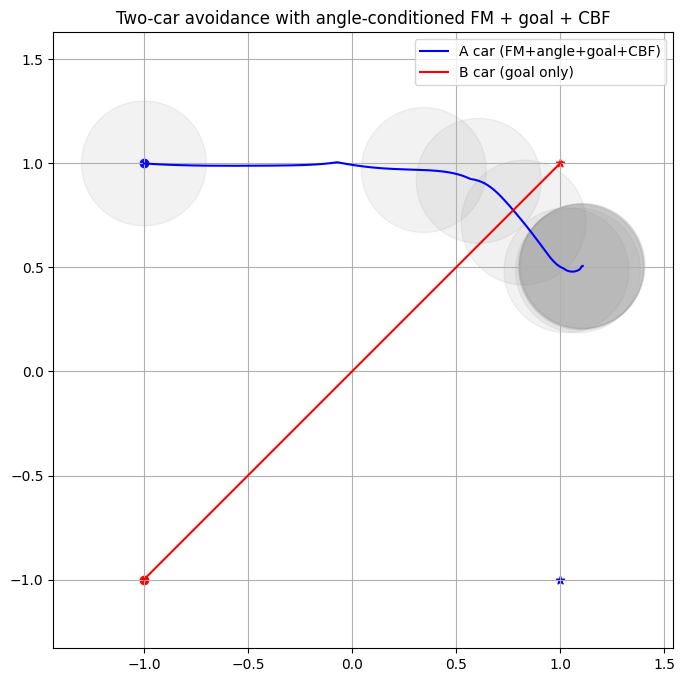

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.plot(xs_A[:, 0], xs_A[:, 1], 'b-', label='A car (FM+angle+goal+CBF)')
plt.plot(xs_B[:, 0], xs_B[:, 1], 'r-', label='B car (goal only)')

plt.scatter(xA_0[0], xA_0[1], c='b', marker='o')
plt.scatter(goal_A[0], goal_A[1], c='b', marker='*')

plt.scatter(xB_0[0], xB_0[1], c='r', marker='o')
plt.scatter(goal_B[0], goal_B[1], c='r', marker='*')

for i in range(0, len(xs_A), max(1, len(xs_A)//10)):
    circle = plt.Circle(xs_A[i], safe_radius, color='gray', alpha=0.1)
    plt.gca().add_patch(circle)

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Two-car avoidance with angle-conditioned FM + goal + CBF")
plt.show()


In [100]:
def compute_goal_heading(x_self, x_goal, device=None):
    """
    x_self, x_goal: (2,) np 或 torch
    返回: 朝向 goal 的角度（弧度）
    """
    if device is None:
        if isinstance(x_self, torch.Tensor):
            device = x_self.device
        else:
            device = "cpu"

    x_self = torch.as_tensor(x_self, dtype=torch.float32, device=device).view(2)
    x_goal = torch.as_tensor(x_goal, dtype=torch.float32, device=device).view(2)

    vec = x_goal - x_self
    theta = torch.atan2(vec[1], vec[0])   # 标量 tensor
    return theta.item()                   # 返回 python float


In [109]:
xA_0 = np.array([-1.0, 1.0], dtype=np.float32)
xB_0 = np.array([-1.0, -1.0], dtype=np.float32)
goal_A = np.array([1.0, -1.0], dtype=np.float32)
goal_B = np.array([1.0, 1.0], dtype=np.float32)

# ⭐ 新增：A 车的“起点指向 goal”的固定角度
theta_cond_A0 = compute_goal_heading(xA_0, goal_A, device=device)

theta_cond_B0 = compute_goal_heading(xB_0, goal_B, device=device)


In [118]:
def mpc_step_A_goal_cbf_angle(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    goal_A: np.ndarray,
    goal_B: np.ndarray,
    theta_cond_A0: float,      # ⭐ 固定：起点→goal_A 的角度
    ellipses=None,
):
    """
    单步 MPC：
      - B 车：简单 goal 控制（直线去 goal_B）
      - A 车：FM(θ_A0) + goal 吸引 → v_nom
              再经过 CBF 投影得到 vA_safe
              再轻微往 goal 方向对齐
      - 返回更新后的 xA, xB 以及速度 vA_safe, vB
    """

    # -------- 1) B 车：简单 goal 控制 --------
    vB = simple_goal_controller(xB, goal_B, v_max=0.4)   # (2,)

    # -------- 2) A 车：FM(固定角度) + goal → v_nom --------
    xA_tensor = torch.tensor(xA, dtype=torch.float32, device=device)

    vA_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xA_tensor,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        theta_cond_A=theta_cond_A0,   # ⭐ 固定的起点→goal_A 角度
        kg=2,                       # goal 吸引力度（可以调）
        lam=0.3,                      # v_nom 中 goal 的权重（可以调）
    )  # (2,)

    # -------- 3) A 车：CBF 投影 --------
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)

    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,                 # 静态椭圆障碍，没有就传 None
        other_agent_pos_2=xB_tensor,       # B 车当作动态圆障碍
        agent_safe_radius=safe_radius,     # 比如 0.35
        extra_margin=0.0,
        max_corr_norm=1.0,                 # 限制修正量，越小越温和
        gamma_min=0.3,                     # Class-K 函数斜率，越小越不保守
        w_p=1.0,                           # 压强场权重（你可以再调）
        press_k=0.5,
        press_n=2.0,
    )  # (2,)

    vA_safe = vA_safe_tensor.detach().cpu().numpy()   # (2,)

    # -------- 4) 在 CBF 结果上，再往 goal_A 方向拉一点 --------
    dir_goal = goal_A - xA
    dist_goal = np.linalg.norm(dir_goal)
    if dist_goal > 1e-6:
        dir_goal = dir_goal / dist_goal              # 单位向量
        speed = np.linalg.norm(vA_safe)
        if speed > 1e-6:
            v_dir = vA_safe / speed
            cos_angle = float(np.dot(v_dir, dir_goal))

            # 若当前速度与 goal 方向夹角太大（>70°），稍微往 goal 拉一拉
            if cos_angle < 0.34:                    # cos(70°) ≈ 0.34
                beta = 0.3                          # 拉回 goal 的力度，可调 0~1
                vA_safe = (1.0 - beta) * vA_safe + beta * speed * dir_goal

    # -------- 5) 欧拉更新 --------
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB * dt

    return xA_next, xB_next, vA_safe, vB


In [120]:
import matplotlib.pyplot as plt

# --------------------------------------------------
#  xs_A, xs_B 需要来自你的主循环：
#  xs_A.shape = (N_steps+1, 2)
#  xs_B.shape = (N_steps+1, 2)
# --------------------------------------------------

plt.figure(figsize=(8, 8))

# -------- A 车轨迹 --------
plt.plot(xs_A[:, 0], xs_A[:, 1], 'b-', linewidth=2,
         label='A car (FM + angle-cond + goal + CBF)')

# -------- B 车轨迹 --------
plt.plot(xs_B[:, 0], xs_B[:, 1], 'r-', linewidth=2,
         label='B car (goal only)')

# -------- 画初始点 / 目标点 --------
plt.scatter(xA_0[0], xA_0[1], c='b', marker='o', s=80)
plt.scatter(goal_A[0], goal_A[1], c='b', marker='*', s=180)

plt.scatter(xB_0[0], xB_0[1], c='r', marker='o', s=80)
plt.scatter(goal_B[0], goal_B[1], c='r', marker='*', s=180)

# -------- 安全圆（画 A 车的）--------
for i in range(0, len(xs_A), max(1, len(xs_A)//12)):
    circle = plt.Circle(xs_A[i], safe_radius, color='gray', alpha=0.12)
    plt.gca().add_patch(circle)

# -------- 图形样式 --------
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.xlabel("X position")
plt.ylabel("Y position")

plt.title("Two-car avoidance with angle-conditioned FM + goal + CBF",
          fontsize=14)

plt.show()


TypeError: list indices must be integers or slices, not tuple

<Figure size 800x800 with 0 Axes>

In [ ]:
def mpc_step_A_goal_cbf_angle(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    goal_A: np.ndarray,
    goal_B: np.ndarray,
    theta_cond_A0: float,      # ⭐ 固定：起点→goal_A 的角度
    ellipses=None,
):
    """
    单步 MPC：
      - B 车：简单 goal 控制（直线去 goal_B）
      - A 车：FM(θ_A0) + goal 吸引 → v_nom
              再经过 CBF 投影得到 vA_safe
              再轻微往 goal 方向对齐
      - 返回更新后的 xA, xB 以及速度 vA_safe, vB
    """

    # -------- 1) B 车：简单 goal 控制 --------
    vB = simple_goal_controller(xB, goal_B, v_max=0.4)   # (2,)

    # -------- 2) A 车：FM(固定角度) + goal → v_nom --------
    xA_tensor = torch.tensor(xA, dtype=torch.float32, device=device)

    vA_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xA_tensor,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        theta_cond_A=theta_cond_A0,   # ⭐ 固定的起点→goal_A 角度
        kg=0.8,                       # goal 吸引力度（可以调）
        lam=0.3,                      # v_nom 中 goal 的权重（可以调）
    )  # (2,)

    # -------- 3) A 车：CBF 投影 --------
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)

    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,                 # 静态椭圆障碍，没有就传 None
        other_agent_pos_2=xB_tensor,       # B 车当作动态圆障碍
        agent_safe_radius=safe_radius,     # 比如 0.35
        extra_margin=0.0,
        max_corr_norm=1.0,                 # 限制修正量，越小越温和
        gamma_min=0.3,                     # Class-K 函数斜率，越小越不保守
        w_p=1.0,                           # 压强场权重（你可以再调）
        press_k=0.5,
        press_n=2.0,
    )  # (2,)

    vA_safe = vA_safe_tensor.detach().cpu().numpy()   # (2,)

    # -------- 4) 在 CBF 结果上，再往 goal_A 方向拉一点 --------
    dir_goal = goal_A - xA
    dist_goal = np.linalg.norm(dir_goal)
    if dist_goal > 1e-6:
        dir_goal = dir_goal / dist_goal              # 单位向量
        speed = np.linalg.norm(vA_safe)
        if speed > 1e-6:
            v_dir = vA_safe / speed
            cos_angle = float(np.dot(v_dir, dir_goal))

            # 若当前速度与 goal 方向夹角太大（>70°），稍微往 goal 拉一拉
            if cos_angle < 0.34:                    # cos(70°) ≈ 0.34
                beta = 0.3                          # 拉回 goal 的力度，可调 0~1
                vA_safe = (1.0 - beta) * vA_safe + beta * speed * dir_goal

    # -------- 5) 欧拉更新 --------
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB * dt

    return xA_next, xB_next, vA_safe, vB


In [123]:
import math

# ===============================================================
# 1. 角度计算 + 支持 theta 条件的 query 函数（兼容老模型）
# ===============================================================

def compute_theta_to_goal(x_now: torch.Tensor, goal: torch.Tensor) -> float:
    """
    根据当前位置 x_now 和目标点 goal 计算朝向角（弧度）。
    返回值范围 [-pi, pi]，例如：
      - 大致朝右下 -> 负角度（比如 -45° ≈ -pi/4）
      - 大致朝右上 -> 正角度
    """
    dx = float(goal[0] - x_now[0])
    dy = float(goal[1] - x_now[1])
    theta = math.atan2(dy, dx)  # 弧度
    return theta


def query_local_velocity_from_unet(
    model,
    x_self: torch.Tensor,      # (2,)
    t_scalar: float,
    N_train: int = 100,
    device: str = "cpu",
    cond_theta = None,
):
    """
    带 theta 条件的单点速度查询（覆盖你之前的版本，向下兼容）：

    - 如果 cond_theta=None，就走你原来的逻辑：model(x_in, t)
    - 如果 cond_theta!=None，会尝试调用 model(x_in, t, theta_tensor)
      如果当前 UNet 还不支持第三个参数，会自动回退到无条件版本。
    """
    x_self = x_self.to(device)

    # 1) 构造伪轨迹: (1,2,N_train)
    x_repeat = x_self.view(2, 1).repeat(1, N_train)  # (2, N_train)
    x_in = x_repeat.unsqueeze(0)                     # (1, 2, N_train)

    # 2) 时间输入
    t = torch.tensor([t_scalar], dtype=torch.float32, device=device)  # (1,)

    # 3) 调用 UNet-1D 模型
    try:
        if cond_theta is None:
            # 老逻辑：只传 (x, t)
            v_all = model(x_in, t)              # 期望输出 (1,2,N_train)
        else:
            # 新逻辑：角度也作为条件
            theta_tensor = torch.tensor(
                [[cond_theta]], dtype=torch.float32, device=device
            )  # 形状 (1,1)，你可以在模型里用 MLP/embedding
            v_all = model(x_in, t, theta_tensor)
    except TypeError:
        # 如果模型当前 forward 只有 (x, t)，直接回退到无条件版本
        v_all = model(x_in, t)

    # 4) 取最后一个时间步的速度当当前点的速度
    v_nom = v_all[0, :, -1]   # (2,)

    return v_nom


# ===============================================================
# 2. 用 Flow Matching 向量场 rollout 一段 horizon 轨迹 (A 和 B 都用 FM)
# ===============================================================

def rollout_AB_with_fm_horizon(
    model,
    xA0: np.ndarray,
    xB0: np.ndarray,
    goal_A: np.ndarray,
    goal_B: np.ndarray,
    horizon: int = 20,
    dt: float = 0.1,
    N_train: int = 100,
    device: torch.device = torch.device("cpu"),
):
    """
    从当前 (xA0, xB0) 出发，用 UNet 向量场 + Euler 积分 rollout 一段 horizon。
    - A、B 都用同一个 flow matching 模型生成名义速度；
    - A、B 的方向条件分别是“当前点朝各自 goal 的角度 theta”。

    返回:
        traj_A_2T: np.ndarray, 形状 (2, T+1)
        traj_B_2T: np.ndarray, 形状 (2, T+1)
    """
    # 转成 torch
    xA = torch.tensor(xA0, dtype=torch.float32, device=device)
    xB = torch.tensor(xB0, dtype=torch.float32, device=device)
    gA = torch.tensor(goal_A, dtype=torch.float32, device=device)
    gB = torch.tensor(goal_B, dtype=torch.float32, device=device)

    # 初始角度（朝 goal）
    thetaA = compute_theta_to_goal(xA, gA)
    thetaB = compute_theta_to_goal(xB, gB)

    traj_A = [xA.clone()]
    traj_B = [xB.clone()]

    for k in range(horizon):
        t_norm = k / max(horizon - 1, 1)

        # UNet 给出 A、B 的名义速度（带 theta 条件）
        vA_nom = query_local_velocity_from_unet(
            model=model,
            x_self=xA,
            t_scalar=t_norm,
            N_train=N_train,
            device=device,
            cond_theta=thetaA,
        )
        vB_nom = query_local_velocity_from_unet(
            model=model,
            x_self=xB,
            t_scalar=t_norm,
            N_train=N_train,
            device=device,
            cond_theta=thetaB,
        )

        # Euler 积分
        xA = xA + vA_nom * dt
        xB = xB + vB_nom * dt

        traj_A.append(xA.clone())
        traj_B.append(xB.clone())

    # 拼成 (2, T+1) 并转成 numpy
    traj_A_tensor = torch.stack(traj_A, dim=0)        # (T+1, 2)
    traj_B_tensor = torch.stack(traj_B, dim=0)        # (T+1, 2)

    traj_A_2T = traj_A_tensor.transpose(0, 1).detach().cpu().numpy()  # (2, T+1)
    traj_B_2T = traj_B_tensor.transpose(0, 1).detach().cpu().numpy()  # (2, T+1)

    return traj_A_2T, traj_B_2T


# ===============================================================
# 3. 简单的 MPC-style 轨迹代价：goal + 平滑 + 利用 B 轨迹避障
# ===============================================================

def compute_traj_cost_mpc(
    traj_A: np.ndarray,          # (2, T)
    goal_A: np.ndarray,          # (2,)
    traj_B: np.ndarray,          # (2, T)
    w_goal_final: float = 5.0,
    w_goal_running: float = 0.1,
    w_smooth: float = 0.1,
    w_collision: float = 10.0,
    safe_radius: float = 0.5,
):
    T = traj_A.shape[1]
    goal_A = goal_A.reshape(2, 1)

    # 1) goal 代价
    dist2 = np.sum((traj_A - goal_A) ** 2, axis=0)   # (T,)
    cost_goal = w_goal_final * dist2[-1] + w_goal_running * np.sum(dist2)

    # 2) 平滑代价
    diff = traj_A[:, 1:] - traj_A[:, :-1]            # (2, T-1)
    smooth2 = np.sum(diff ** 2, axis=0)
    cost_smooth = w_smooth * np.sum(smooth2)

    # 3) 与 B 的碰撞代价（利用 FM rollout 出来的 B 轨迹）
    cost_coll = 0.0
    if traj_B is not None:
        Tb = min(T, traj_B.shape[1])
        d = traj_A[:, :Tb] - traj_B[:, :Tb]          # (2, Tb)
        d2 = np.sum(d ** 2, axis=0)
        dist = np.sqrt(d2 + 1e-8)
        # hinge: 距离小于 safe_radius 时给惩罚
        penalty = np.clip(safe_radius - dist, 0.0, None) ** 2
        cost_coll = w_collision * np.sum(penalty)

    return float(cost_goal + cost_smooth + cost_coll)


# ===============================================================
# 4. 单步 MPC step：用 horizon rollout 决定当前一步的名义速度，再接 CBF
# ===============================================================

def mpc_step_A_with_fm_horizon_and_cbf(
    xA: np.ndarray,
    xB: np.ndarray,
    goal_A: np.ndarray,
    goal_B: np.ndarray,
    model,
    ellipses=None,
    horizon: int = 20,
    dt: float = 0.1,
    N_train: int = 100,
    device: torch.device = torch.device("cpu"),
):
    """
    单步：
      1) 用 Flow Matching + angle 条件 rollout 一段 (A, B) 的名义轨迹；
      2) 对 A 轨迹算 MPC-style 代价（goal + 平滑 + 和 B 的相对距离）；
         （这里只生成一条轨迹，主要目的是：决策时看到 horizon 上的信息）
      3) 用 A 轨迹的第一步速度作为 vA_nom，送进 CBF 单步投影；
      4) B 直接用自己的 FM 名义速度前进一步。
    """
    # 1) horizon rollout：A、B 都由 FM 模型生成名义轨迹
    traj_A_2T, traj_B_2T = rollout_AB_with_fm_horizon(
        model=model,
        xA0=xA,
        xB0=xB,
        goal_A=goal_A,
        goal_B=goal_B,
        horizon=horizon,
        dt=dt,
        N_train=N_train,
        device=device,
    )

    # 2) 计算 A 轨迹在这一段 horizon 上的 MPC-style cost（主要用来 debug/画图）
    cost_A = compute_traj_cost_mpc(
        traj_A=traj_A_2T,
        goal_A=np.asarray(goal_A, dtype=np.float32),
        traj_B=traj_B_2T,
    )

    # 3) 从最前两个点拿出第一步速度，作为名义速度
    vA_nom = (traj_A_2T[:, 1] - traj_A_2T[:, 0]) / dt   # (2,)
    vB_nom = (traj_B_2T[:, 1] - traj_B_2T[:, 0]) / dt   # (2,)

    # 4) CBF 投影只对 A 做（你也可以对 B 再做一遍）
    xA_t = torch.tensor(xA, dtype=torch.float32, device=device)
    xB_t = torch.tensor(xB, dtype=torch.float32, device=device)
    vA_nom_t = torch.tensor(vA_nom, dtype=torch.float32, device=device)

    vA_safe_t = cbf_project_velocity_step(
        x_now_2=xA_t,
        v_nom_2=vA_nom_t,
        ellipses=ellipses or [],
        other_agent_pos_2=xB_t,
        agent_safe_radius=0.5,
        extra_margin=0.0,
        max_corr_norm=2.0,
        gamma_min=1.0,
        w_p=5.0,
        press_k=1.0,
        press_n=2.0,
    )

    vA_safe = vA_safe_t.detach().cpu().numpy()

    # 5) Euler 更新（A 用 CBF 保护，B 用自己的 FM 名义速度）
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB_nom * dt

    return xA_next, xB_next, vA_safe, vB_nom, traj_A_2T, traj_B_2T, cost_A


In [135]:
safe_radius = 0.3   # 你 CBF 里用的 agent_safe_radius

def mpc_step_A_goal_cbf_angle(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    goal_A: np.ndarray,
    goal_B: np.ndarray,
    ellipses=None,
):
    # ---- 1) 计算 angle condition ----
    # A 的角度条件：从 A 出发，结合 B 和 goal_A 的信息
    theta_cond_A = compute_angle_condition(xA, xB, goal_A, device=device)
    # B 的角度条件：从 B 出发，结合 A 和 goal_B 的信息（和上面对称）
    theta_cond_B = compute_angle_condition(xB, xA, goal_B, device=device)

    # ---- 2) A / B 转成 tensor ----
    xA_tensor = torch.tensor(xA, dtype=torch.float32, device=device)
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)

    # ---- 3) A 车：FM + goal → vA_nom ----
    vA_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xA_tensor,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        theta_cond_A=theta_cond_A,   # ⭐ 角度条件真正用上了
        kg=0.8,
        lam=0.3,
    )

    # ---- 4) B 车：也用 FM + goal_B → vB_nom （不再用 simple_goal_controller）----
    vB_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xB_tensor,         # 这里“xA_tensor”这个名字只是函数形参，实参传的是 B 位置
        t_norm=t_norm,
        model=model,
        goal_A=goal_B,               # 对 B 来说，它的 goal 就是 goal_B
        theta_cond_A=theta_cond_B,   # 用为 B 算的角度条件
        kg=0.8,
        lam=0.3,
    )

    vB = vB_nom_tensor.detach().cpu().numpy()

    # ---- 5) A 车：CBF 投影 ----
    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,
        other_agent_pos_2=xB_tensor,
        agent_safe_radius=safe_radius,
        extra_margin=0.0,
        max_corr_norm=1.0,
        gamma_min=1.0,
        w_p=1.0,
        press_k=1.0,
        press_n=2.0,
    )

    vA_safe = vA_safe_tensor.detach().cpu().numpy()

    # ========= 可选：沿着 goal 再拉一点方向 =========
    dir_goal = goal_A - xA
    dist_goal = np.linalg.norm(dir_goal)
    if dist_goal > 1e-6:
        dir_goal = dir_goal / dist_goal           # 单位向量
        speed = np.linalg.norm(vA_safe)
        if speed > 1e-6:
            v_dir = vA_safe / speed              # 当前速度方向
            cos_angle = np.dot(v_dir, dir_goal)  # 和 goal 方向的余弦

            # 如果和 goal 的方向夹角太大（比如 > 70 度），就往 goal 拉一点
            if cos_angle < 0.34:  # cos(70°) ≈ 0.34
                beta = 0.3        # 拉回 goal 的力度，0~1 之间自己调
                vA_safe = (1.0 - beta) * vA_safe + beta * speed * dir_goal
    # =============================================================

    # ---- 6) 欧拉更新 ----
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB * dt

    return xA_next, xB_next, vA_safe, vB


In [137]:
safe_radius = 0.3   # CBF 里 agent_safe_radius
dt = 0.1            # 仿真时间步长（如果你原来用的不是 0.1，就改成原来的）

def mpc_step_A_goal_cbf_angle(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    goal_A: np.ndarray,
    goal_B: np.ndarray,
    ellipses=None,
):
    """
    单步：
      - A: Flow Matching + goal + angle -> v_nom，再经过 CBF 投影成为 v_safe
      - B: Flow Matching + goal + angle -> v_nom（不做 CBF）
    """
    # ---------- 1) 角度条件 ----------
    theta_cond_A = compute_angle_condition(xA, xB, goal_A, device=device)
    theta_cond_B = compute_angle_condition(xB, xA, goal_B, device=device)

    # ---------- 2) 转成 tensor ----------
    xA_tensor = torch.tensor(xA, dtype=torch.float32, device=device)
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)

    # ---------- 3) A: FM + goal ----------
    vA_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xA_tensor,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        theta_cond_A=theta_cond_A,
        kg=0.8,
        lam=0.3,
    )

    # ---------- 4) B: FM + goal_B ----------
    vB_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xB_tensor,       # 这里形参叫 xA_tensor，但传的是 B 的位置
        t_norm=t_norm,
        model=model,
        goal_A=goal_B,
        theta_cond_A=theta_cond_B,
        kg=0.8,
        lam=0.3,
    )

    vB = vB_nom_tensor.detach().cpu().numpy()

    # ---------- 5) A: CBF 投影 ----------
    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,
        other_agent_pos_2=xB_tensor,
        agent_safe_radius=safe_radius,
        extra_margin=0.0,
        max_corr_norm=1.0,
        gamma_min=1.0,
        w_p=1.0,
        press_k=1.0,
        press_n=2.0,
    )

    vA_safe = vA_safe_tensor.detach().cpu().numpy()

    # ---------- 6) 可选：沿 goal 再拉一点方向 ----------
    dir_goal = goal_A - xA
    dist_goal = np.linalg.norm(dir_goal)
    if dist_goal > 1e-6:
        dir_goal = dir_goal / dist_goal
        speed = np.linalg.norm(vA_safe)
        if speed > 1e-6:
            v_dir = vA_safe / speed
            cos_angle = np.dot(v_dir, dir_goal)
            if cos_angle < 0.34:      # cos(70°)
                beta = 0.3
                vA_safe = (1.0 - beta) * vA_safe + beta * speed * dir_goal

    # ---------- 7) 欧拉更新 ----------
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB * dt

    return xA_next, xB_next, vA_safe, vB


In [138]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def simulate_and_plot(
    model,
    xA0: np.ndarray,
    xB0: np.ndarray,
    goal_A: np.ndarray,
    goal_B: np.ndarray,
    ellipses=None,
    T_steps: int = 80,
):
    # ---- 初始化状态 ----
    xA = xA0.astype(np.float32).copy()
    xB = xB0.astype(np.float32).copy()

    xs_A = [xA.copy()]
    xs_B = [xB.copy()]

    # ---- 主循环 ----
    for k in range(T_steps):
        t_norm = k / max(T_steps - 1, 1)

        xA, xB, vA_safe, vB = mpc_step_A_goal_cbf_angle(
            xA=xA,
            xB=xB,
            t_norm=t_norm,
            model=model,
            goal_A=goal_A,
            goal_B=goal_B,
            ellipses=ellipses,
        )

        xs_A.append(xA.copy())
        xs_B.append(xB.copy())

    xs_A = np.asarray(xs_A)   # (T+1, 2)
    xs_B = np.asarray(xs_B)

    # ---- 画图 ----
    plt.figure(figsize=(8, 8))

    # A 轨迹
    plt.plot(xs_A[:, 0], xs_A[:, 1], 'b-', label='A car (FM+angle+goal+CBF)')
    plt.scatter(xs_A[0, 0], xs_A[0, 1], c='b', marker='o', label='A start')
    plt.scatter(goal_A[0], goal_A[1], c='b', marker='*', s=100, label='A goal')

    # B 轨迹
    plt.plot(xs_B[:, 0], xs_B[:, 1], 'r-', label='B car (FM+angle+goal)')
    plt.scatter(xs_B[0, 0], xs_B[0, 1], c='r', marker='o', label='B start')
    plt.scatter(goal_B[0], goal_B[1], c='r', marker='*', s=100, label='B goal')

    # A 的安全圆（示意 CBF 的安全距离）
    for i in range(0, len(xs_A), max(1, len(xs_A)//10)):
        circle = patches.Circle(
            (xs_A[i, 0], xs_A[i, 1]),
            safe_radius,
            color='gray',
            alpha=0.1
        )
        plt.gca().add_patch(circle)

    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.title("Two-car avoidance with angle-conditioned FM + goal + CBF")
    plt.show()

    return xs_A, xs_B


In [144]:
import numpy as np

N = 1000   # 多少条轨迹
T = 50     # 每条轨迹长度

trajectories = np.zeros((N, 2, T), dtype=np.float32)
thetas = np.random.uniform(-np.pi, np.pi, size=N).astype(np.float32)  # 每条轨迹一个 θ

# ★ 固定一个全局起点（你可以改成任何你喜欢的位置）
x0_global = 0.0
y0_global = 0.0

for i in range(N):
    theta = thetas[i]

    # ---- 起点不再随机，全部用同一个 ----
    x0 = x0_global
    y0 = y0_global
    trajectories[i, 0, 0] = x0
    trajectories[i, 1, 0] = y0

    # 每一步平均步长
    step = np.random.uniform(0.05, 0.15)

    for t in range(1, T):
        # 沿 theta 前进 + 少量噪声
        dx = step * np.cos(theta) + 0.02 * np.random.randn()
        dy = step * np.sin(theta) + 0.02 * np.random.randn()

        trajectories[i, 0, t] = trajectories[i, 0, t-1] + dx
        trajectories[i, 1, t] = trajectories[i, 1, t-1] + dy

print("trajectories.shape:", trajectories.shape)  # (N, 2, T)
print("thetas.shape:", thetas.shape)              # (N,)


trajectories.shape: (1000, 2, 50)
thetas.shape: (1000,)


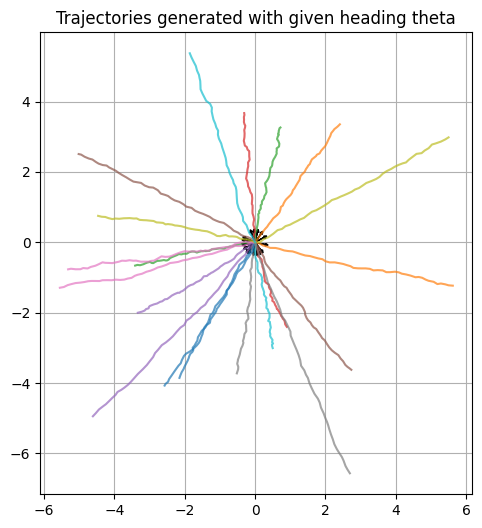

In [145]:
import matplotlib.pyplot as plt

def visualize_conditional_dataset(trajectories, thetas, num_display=20):
    N = len(trajectories)
    num_display = min(num_display, N)

    plt.figure(figsize=(6, 6))
    for i in range(num_display):
        traj = trajectories[i]   # (2, T)
        x = traj[0]
        y = traj[1]
        theta = thetas[i]

        plt.plot(x, y, alpha=0.7)

        # 在起点画一个指向 theta 的箭头
        x0, y0 = x[0], y[0]
        arrow_len = 0.3
        dx = arrow_len * np.cos(theta)
        dy = arrow_len * np.sin(theta)
        plt.arrow(x0, y0, dx, dy, head_width=0.08, head_length=0.08, color='k')

    plt.gca().set_aspect('equal', 'box')
    plt.grid(True)
    plt.title("Trajectories generated with given heading theta")
    plt.show()

visualize_conditional_dataset(trajectories, thetas, num_display=20)


In [146]:
import torch
from torch.utils.data import Dataset, DataLoader

class TrajectoryDataset(Dataset):
    def __init__(self, trajectories: np.ndarray, thetas: np.ndarray):
        assert len(trajectories) == len(thetas)
        self.trajectories = trajectories.astype(np.float32)
        self.thetas = thetas.astype(np.float32)
    
    def __len__(self):
        return len(self.trajectories)
    
    def __getitem__(self, idx):
        traj = torch.tensor(self.trajectories[idx], dtype=torch.float32)  # (2, T)
        theta = torch.tensor(self.thetas[idx], dtype=torch.float32)       # ()
        return traj, theta

dataset = TrajectoryDataset(trajectories, thetas)
loader = DataLoader(dataset, batch_size=64, shuffle=True)


In [150]:
import numpy as np

N = 1000
T = 50
K = 15          # 前 K 步按 theta 发散，后 T-K 步朝 goal 收拢

trajectories = np.zeros((N, 2, T), dtype=np.float32)
thetas = np.random.uniform(-np.pi, np.pi, size=N).astype(np.float32)

# 固定起点和终点
x0_global = 0.0
y0_global = 0.0
goal = np.array([4.0, 3.0], dtype=np.float32)

for i in range(N):
    theta0 = thetas[i]
    dir_init = np.array([np.cos(theta0), np.sin(theta0)], dtype=np.float32)

    # 初始位置
    x = x0_global
    y = y0_global
    trajectories[i, :, 0] = [x, y]

    # ====== 前 K 步：仅沿 theta0 走（+一点点噪声） ======
    step1 = np.random.uniform(0.08, 0.15)
    for t in range(1, K):
        dx = step1 * dir_init[0] + 0.01 * np.random.randn()
        dy = step1 * dir_init[1] + 0.01 * np.random.randn()
        x += dx
        y += dy
        trajectories[i, :, t] = [x, y]

    # ====== 后 T-K 步：平均分成 T-K 段朝 goal 走 ======
    # 剩余距离
    rem_vec = goal - np.array([x, y], dtype=np.float32)
    rem_steps = T - K
    if rem_steps <= 0:
        rem_steps = 1
    step_vec = rem_vec / rem_steps    # 每步往 goal 走同样的一小段

    for t in range(K, T):
        # 可以给一点很小的噪声，也可以直接用 step_vec
        dx = step_vec[0] + 0.005 * np.random.randn()
        dy = step_vec[1] + 0.005 * np.random.randn()
        x += dx
        y += dy
        trajectories[i, :, t] = [x, y]

    # 最后一步直接钉在 goal 上，避免数值飘
    trajectories[i, :, -1] = goal

print("trajectories.shape:", trajectories.shape)
print("thetas.shape:", thetas.shape)


trajectories.shape: (1000, 2, 50)
thetas.shape: (1000,)


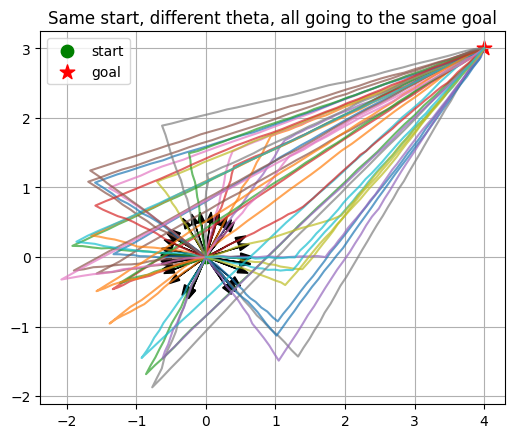

In [151]:
import matplotlib.pyplot as plt

def visualize_conditional_dataset(trajectories, thetas, goal, num_display=30):
    N = len(trajectories)
    num_display = min(num_display, N)

    plt.figure(figsize=(6, 6))
    for i in range(num_display):
        traj = trajectories[i]
        x = traj[0]
        y = traj[1]
        theta = thetas[i]

        plt.plot(x, y, alpha=0.7)
        # 起点箭头 = 初始 heading θ
        x0, y0 = x[0], y[0]
        arrow_len = 0.5
        plt.arrow(
            x0, y0,
            arrow_len * np.cos(theta),
            arrow_len * np.sin(theta),
            head_width=0.1, head_length=0.15, color="k"
        )

    # 起点和共同 goal
    plt.scatter(x0_global, y0_global, c="g", s=80, label="start")
    plt.scatter(goal[0], goal[1], c="r", s=120, marker="*", label="goal")

    plt.gca().set_aspect("equal", "box")
    plt.grid(True)
    plt.legend()
    plt.title("Same start, different theta, all going to the same goal")
    plt.show()

visualize_conditional_dataset(trajectories, thetas, goal, num_display=40)


In [152]:
import numpy as np

N = 1000
T = 50

trajectories = np.zeros((N, 2, T), dtype=np.float32)
thetas = np.random.uniform(-np.pi, np.pi, size=N).astype(np.float32)

x0_global = 0.0
y0_global = 0.0
goal = np.array([4.0, 3.0], dtype=np.float32)

for i in range(N):
    theta0 = thetas[i]
    dir_init = np.array([np.cos(theta0), np.sin(theta0)], dtype=np.float32)

    x = x0_global
    y = y0_global
    trajectories[i, :, 0] = [x, y]

    for t in range(1, T):
        # 当前朝向 goal 的方向
        vec_goal = goal - np.array([x, y], dtype=np.float32)
        dist_goal = np.linalg.norm(vec_goal) + 1e-8
        dir_goal = vec_goal / dist_goal

        # w 从 1 平滑减到 0（前面更看 initial theta，后面更看 goal）
        # 你可以调 T/3 这个系数，控制拐弯快慢
        w = np.exp(- t / (T / 3.0))      # t=0 附近 w≈1，后面逐渐接近 0

        dir_mix = w * dir_init + (1.0 - w) * dir_goal
        dir_mix = dir_mix / (np.linalg.norm(dir_mix) + 1e-8)

        step = 0.12                      # 固定步长更平滑
        dx = step * dir_mix[0] + 0.005 * np.random.randn()
        dy = step * dir_mix[1] + 0.005 * np.random.randn()

        x += dx
        y += dy
        trajectories[i, :, t] = [x, y]

    # 最后一点拉到 goal，保证所有轨迹终点一致
    trajectories[i, :, -1] = goal


In [153]:
import numpy as np

N = 1000
T = 50

trajectories = np.zeros((N, 2, T), dtype=np.float32)
thetas = np.random.uniform(-np.pi, np.pi, size=N).astype(np.float32)

x0_global = 0.0
y0_global = 0.0
goal = np.array([4.0, 3.0], dtype=np.float32)

for i in range(N):
    theta0 = thetas[i]
    dir_init = np.array([np.cos(theta0), np.sin(theta0)], dtype=np.float32)

    x = x0_global
    y = y0_global
    trajectories[i, :, 0] = [x, y]

    for t in range(1, T):
        # 当前朝向 goal 的方向
        vec_goal = goal - np.array([x, y], dtype=np.float32)
        dist_goal = np.linalg.norm(vec_goal) + 1e-8
        dir_goal = vec_goal / dist_goal

        # w 从 1 平滑减到 0（前面更看 initial theta，后面更看 goal）
        # 你可以调 T/3 这个系数，控制拐弯快慢
        w = np.exp(- t / (T / 3.0))      # t=0 附近 w≈1，后面逐渐接近 0

        dir_mix = w * dir_init + (1.0 - w) * dir_goal
        dir_mix = dir_mix / (np.linalg.norm(dir_mix) + 1e-8)

        step = 0.12                      # 固定步长更平滑
        dx = step * dir_mix[0] + 0.005 * np.random.randn()
        dy = step * dir_mix[1] + 0.005 * np.random.randn()

        x += dx
        y += dy
        trajectories[i, :, t] = [x, y]

    # 最后一点拉到 goal，保证所有轨迹终点一致
    trajectories[i, :, -1] = goal


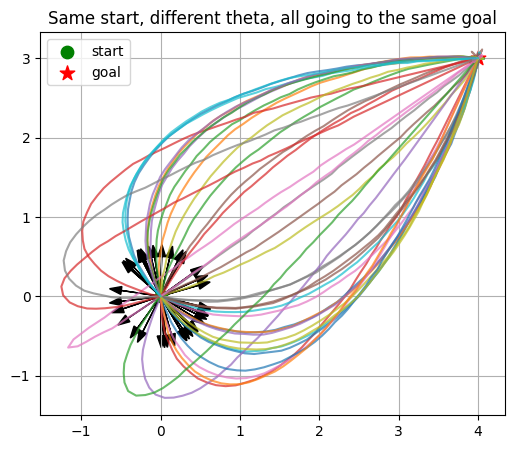

In [154]:
visualize_conditional_dataset(trajectories, thetas, goal, num_display=40)
